# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 51.6 MB/s eta 0:00:00


In [2]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [4]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Loading the train and test set
path="/content/drive/MyDrive/AI-ML Course/ReneWind/Train.csv"
df = pd.read_csv(path)

path2="/content/drive/MyDrive/AI-ML Course/ReneWind/Test.csv"
df_test = pd.read_csv(path2)

In [6]:
# Copying the training and test data
# so that we have the original copy if we need it
data = df.copy()
data_test = df_test.copy()

# **Data Overview**

In [ ]:
# Using shape to get the number of rows and columns
data.shape

(20000, 41)

- *We see that the data has 20,000 rows and 41 columns.*

In [ ]:
# Using shape to get the number of rows and columns for test set
data_test.shape

(5000, 41)

- *We have 5000 rows in the test data.*

In [ ]:
# Using sample to view some sample rows in the data
data.sample(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
17836,-2.138950,-2.172505,4.159787,2.422040,0.086578,-6.346185,-1.317920,6.792116,-2.578302,0.588464,...,6.075253,-5.619910,1.926889,3.659934,5.618616,1.092818,-7.730812,0.452819,-1.387529,0
16576,NaN,3.933815,-0.761930,2.651889,1.753614,-0.554092,1.829107,-0.105409,-3.737081,1.036776,...,3.486408,1.028094,2.845747,1.744060,-1.999615,-0.783041,8.698449,0.352489,-2.005397,0
10245,-1.843865,5.717342,6.000384,4.721106,0.794458,-4.013026,2.362073,2.536665,-2.618477,-0.359190,...,-0.422037,-1.472280,4.585736,2.106415,-0.272344,-1.545613,2.344175,0.765824,-1.858069,0
16612,1.650119,6.858772,0.508811,-2.732274,2.341667,3.435201,2.239164,-0.467592,-1.948638,-4.646407,...,-2.843827,8.189523,-5.742802,0.363232,-4.904118,-0.331306,5.693486,-2.479316,7.254805,0
13795,1.137444,2.589616,4.201284,-0.867214,1.470939,-0.143800,-0.019902,-2.100427,-0.121892,0.747797,...,-0.715804,-0.068628,-1.331090,0.460798,2.987938,-1.239377,1.567667,1.225640,0.782696,0


In [ ]:
# Using sample to view some sample rows in test data
data_test.sample(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
767,2.868964,4.351829,6.267948,-0.194788,-0.532854,1.925277,-0.608387,-9.703214,2.261915,2.628395,...,-4.833753,2.478450,0.124073,4.077302,0.460741,-3.458085,8.582029,2.925407,-4.163161,0
2117,-6.406180,-8.447461,2.067940,-2.041326,1.070259,-1.753307,-7.306976,-0.007783,0.304093,3.071743,...,11.250429,2.631189,-4.269158,4.489181,9.761117,1.205526,-9.365420,3.119183,-4.027300,0
1329,0.226123,-1.422601,6.347675,1.777267,-2.066452,-2.778701,-2.800853,-1.108261,0.268936,2.038818,...,2.452718,0.734544,0.717100,8.104522,2.541798,-1.687632,-2.692589,1.165533,-4.884405,0
1100,-0.087791,-0.809136,-0.244771,0.107734,-1.892557,1.476036,2.954464,2.513532,-1.145432,-1.712156,...,-13.314862,-3.215869,5.813936,-6.562744,-1.906281,2.303503,0.505365,-0.845008,6.128477,1
4423,-0.361615,1.673349,-2.872562,-7.740876,3.543375,4.270073,-2.009514,-2.261632,1.050937,-4.843437,...,2.196033,8.205859,-11.893592,-1.230516,0.661946,2.473265,-0.161313,-0.132221,6.515536,0


In [ ]:
# Checking column data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

- *We see that all the variables are numerical (float or int).*

In [ ]:
# Checking statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


- *We see that all the variables are numerical (float or int).*

In [ ]:
# checking null values in the data
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


- *The features V1 and V2 have some null data, which we can impute later on.*

In [ ]:
# checking null values in the test data
data_test.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


- *Again we see that V1 and V2 have some null data.*
- *We will impute these values after train val split to avoid data leakage.*

# **Exploratory Data Analysis**

## Univariate analysis

In [7]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [8]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=True, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

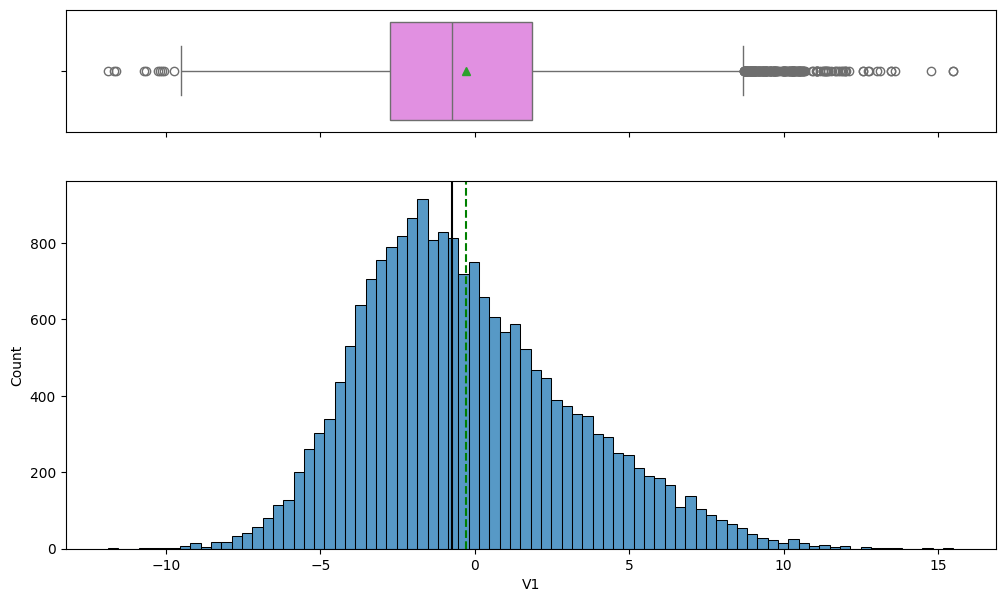

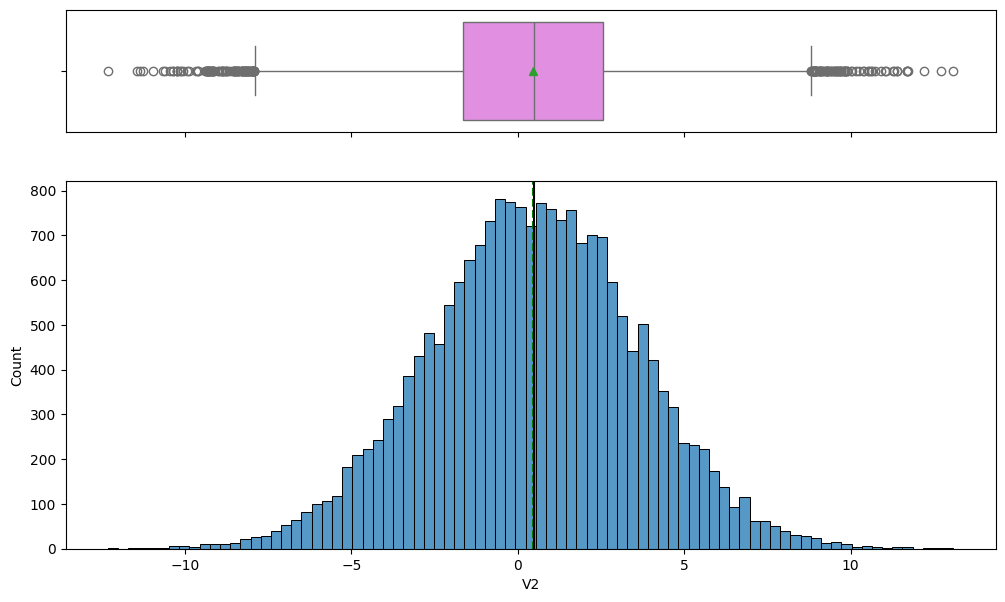

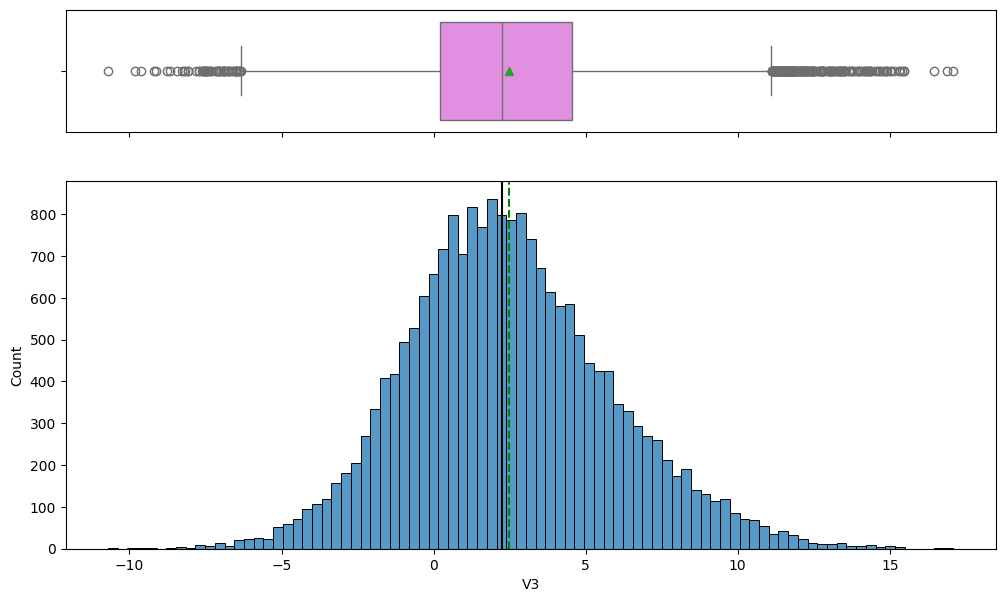

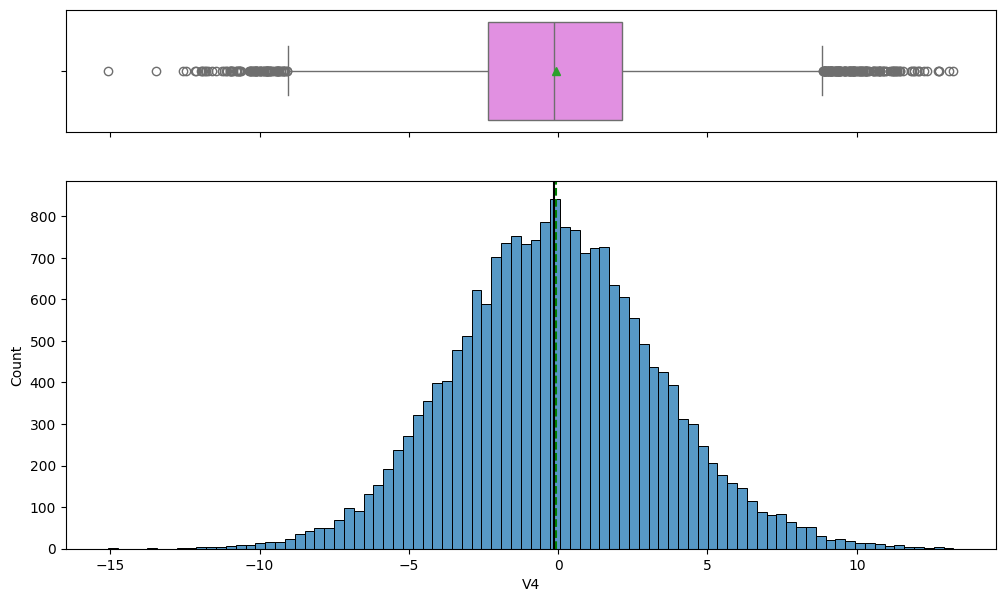

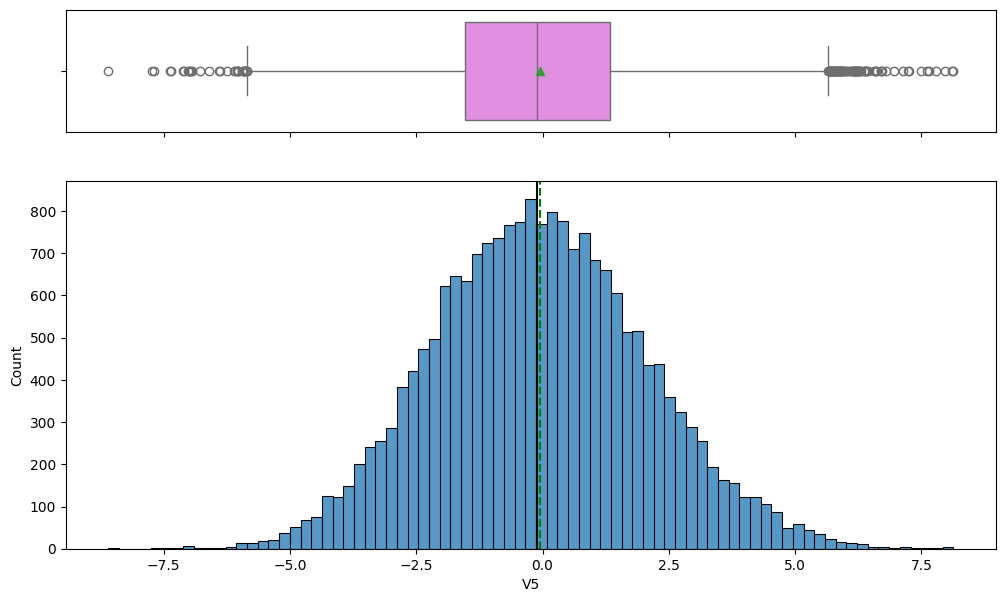

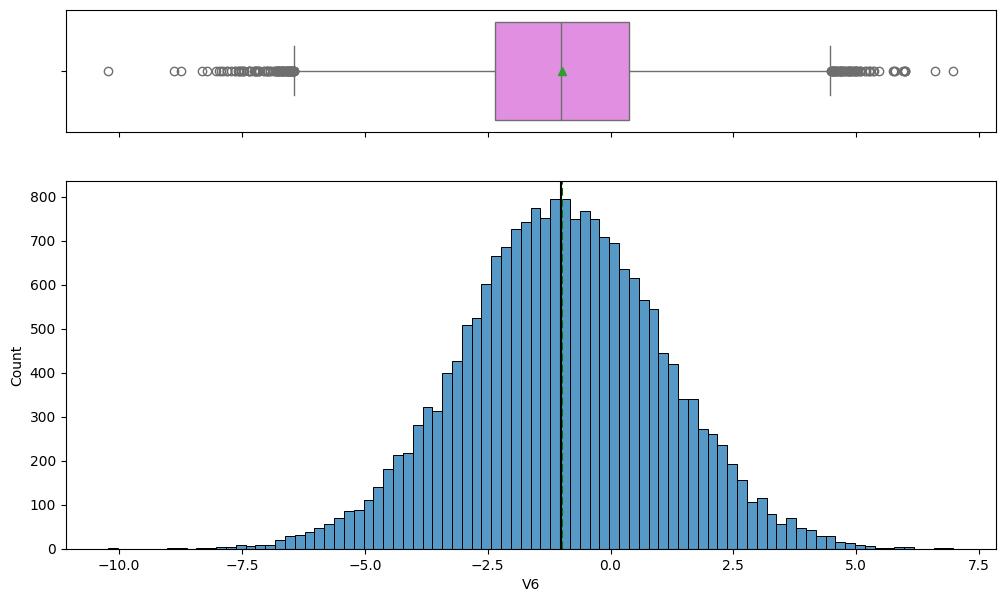

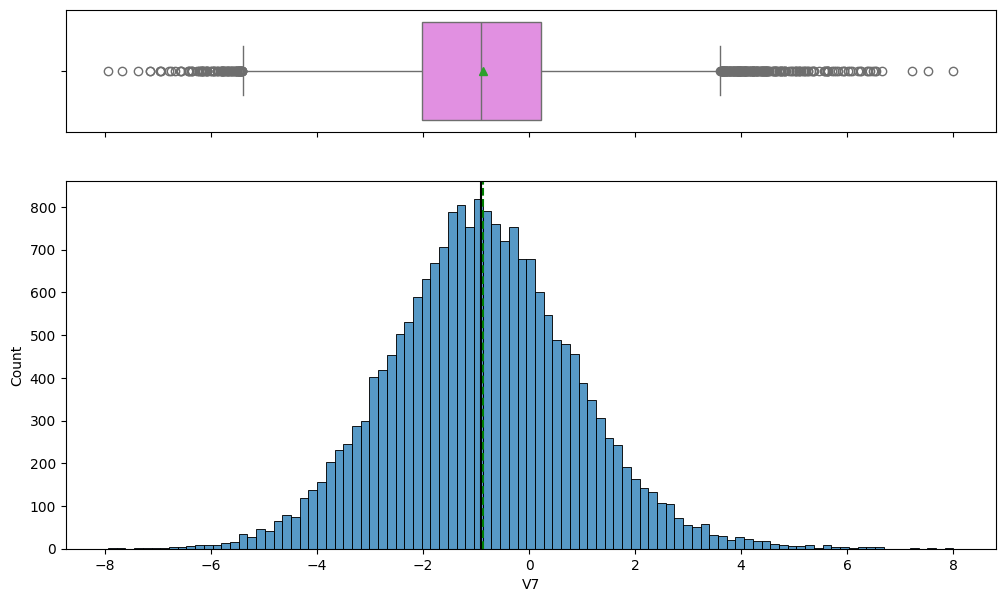

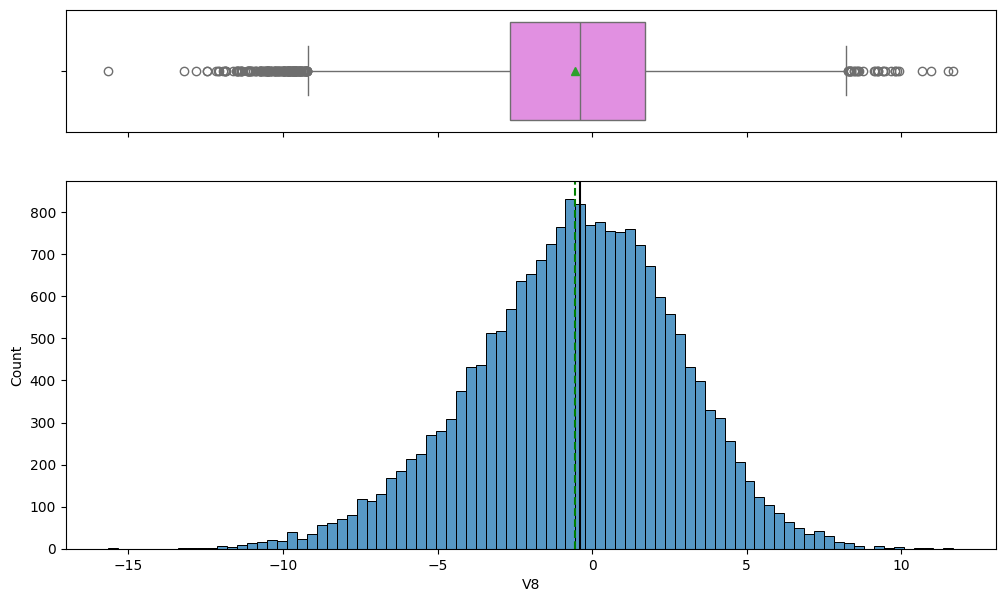

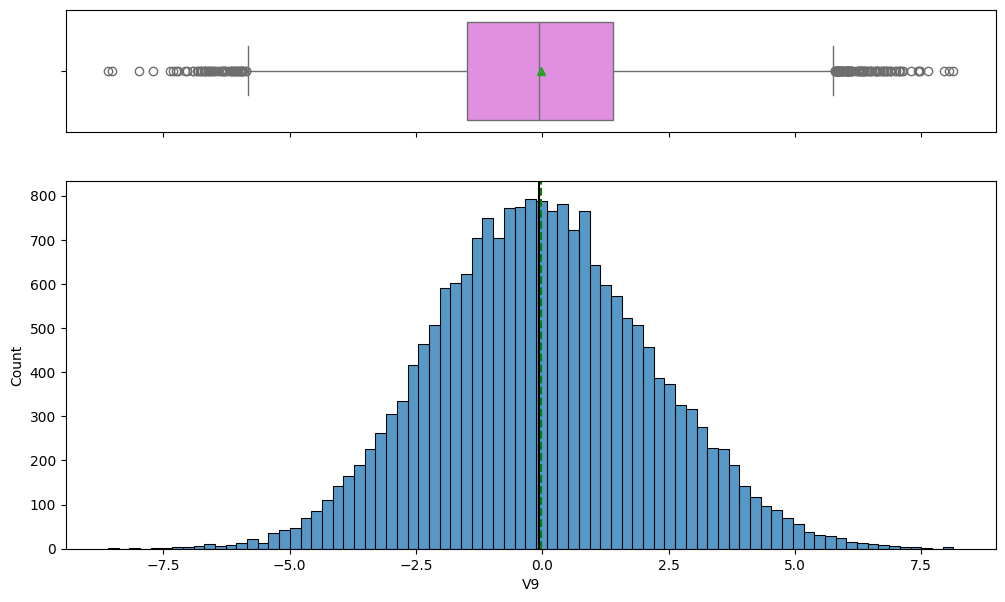

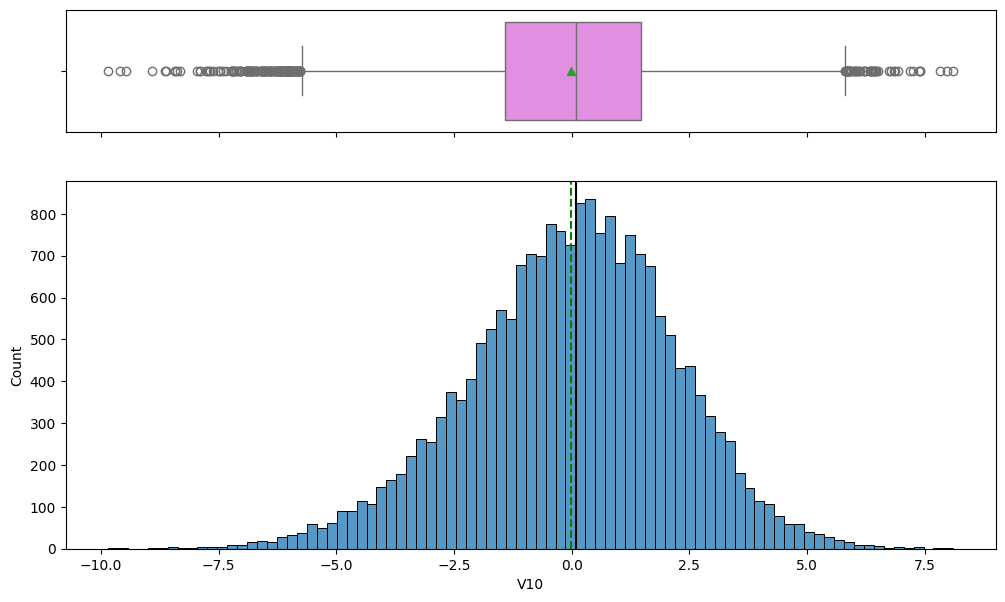

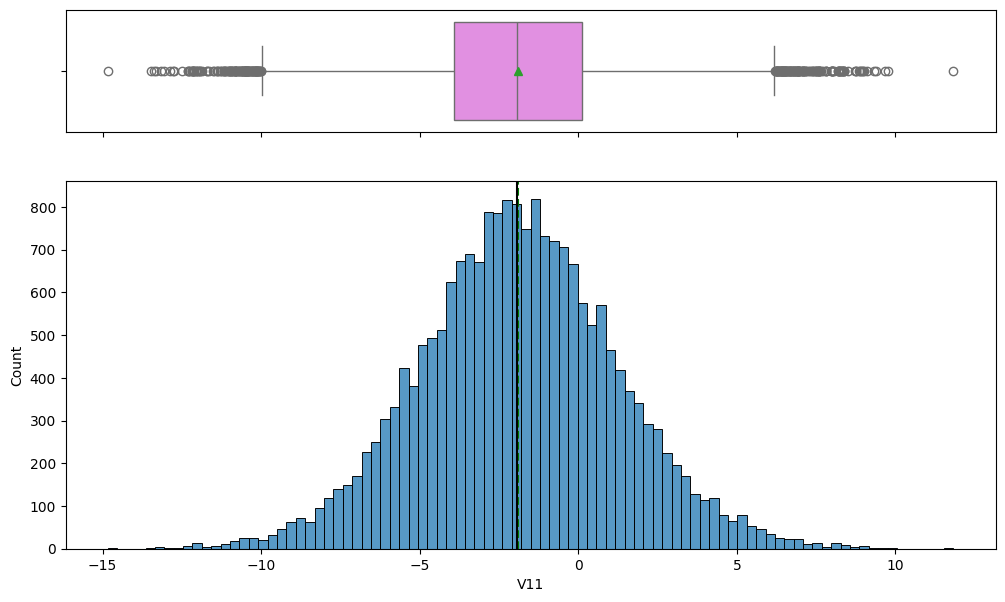

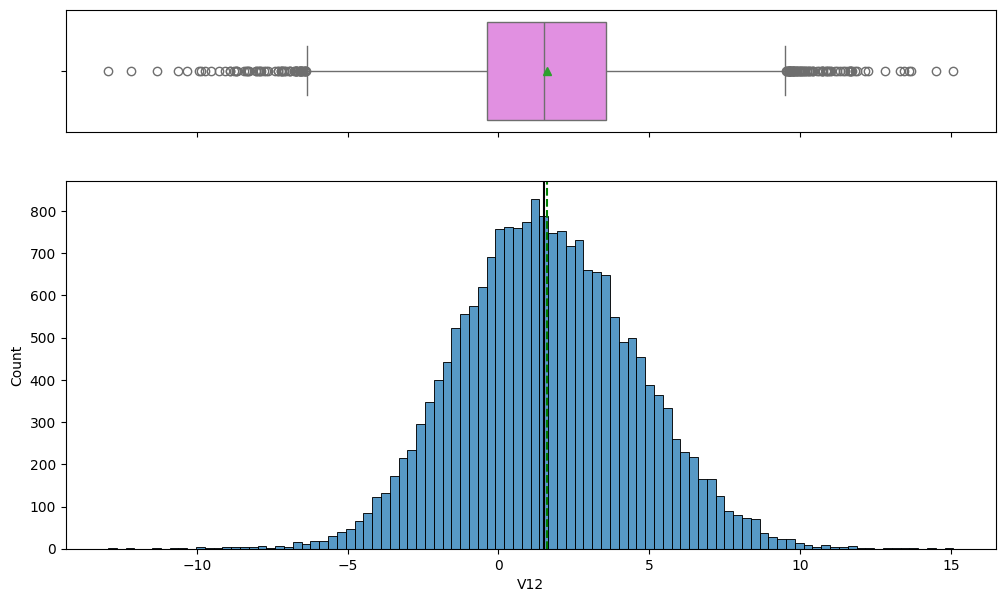

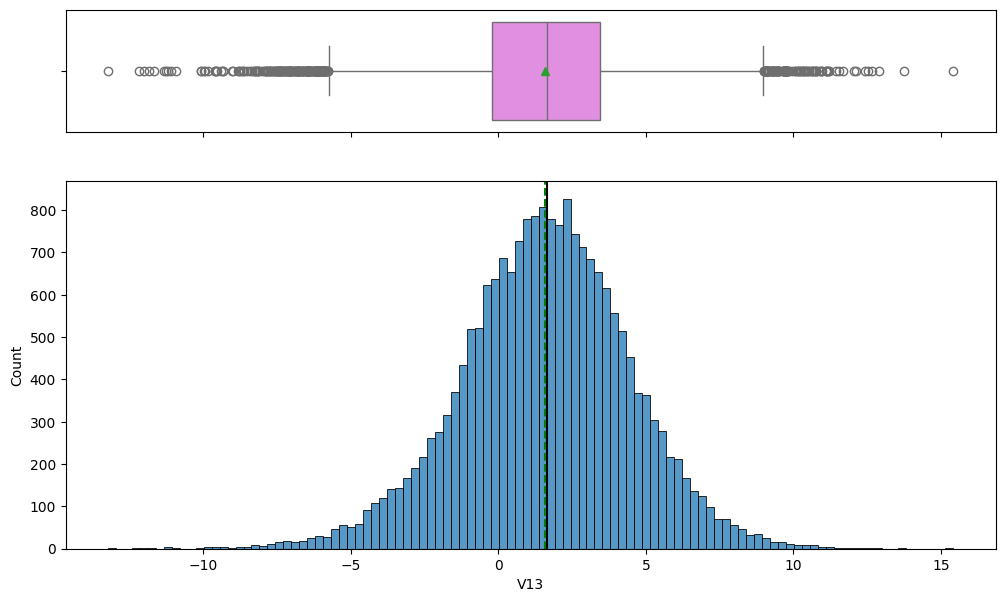

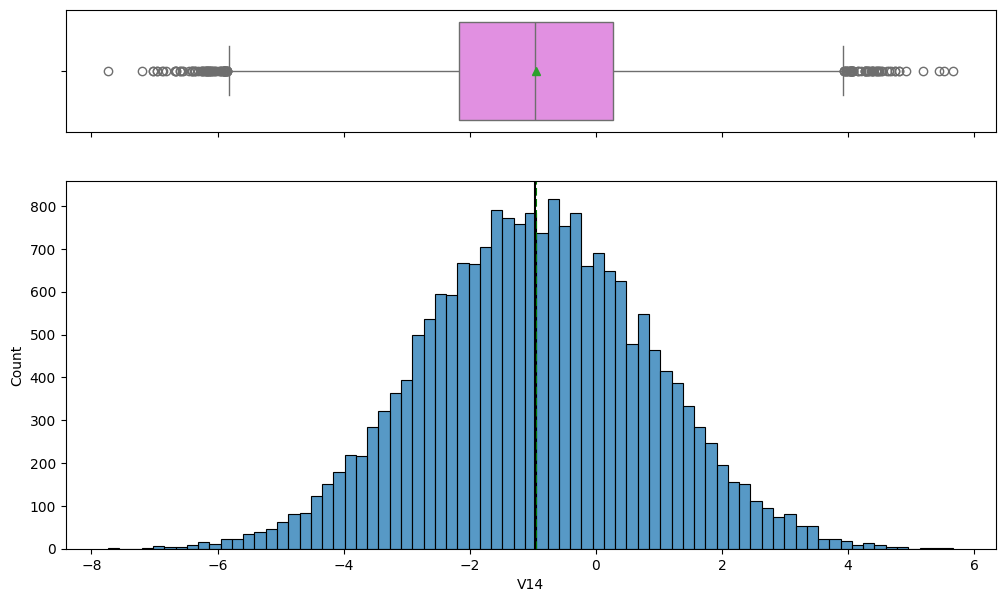

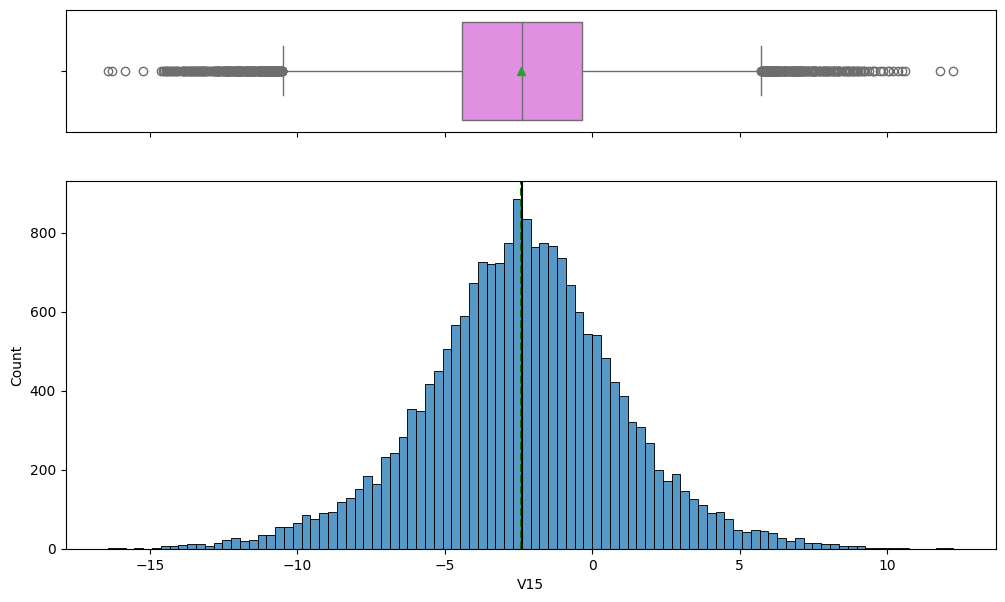

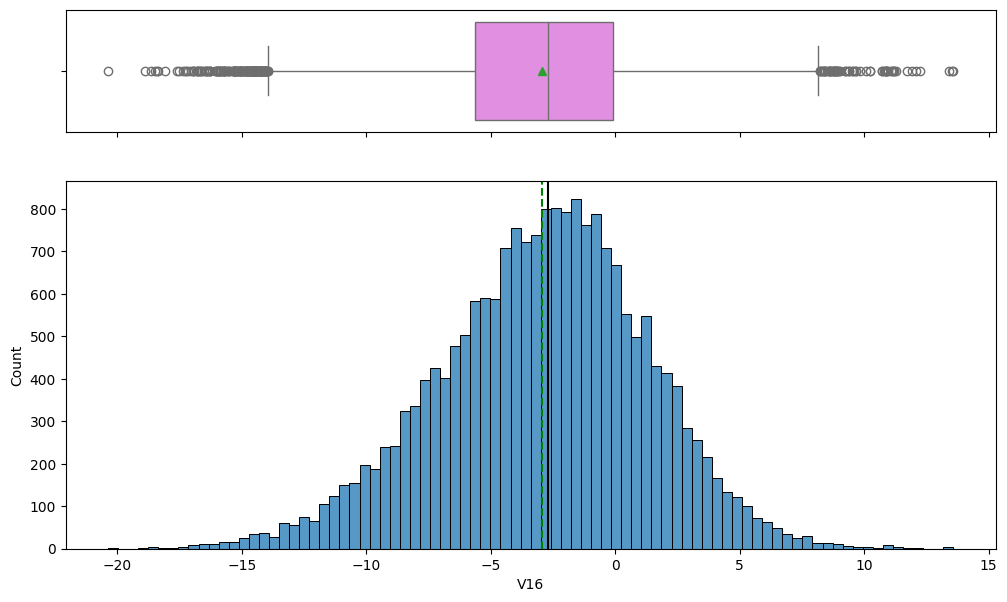

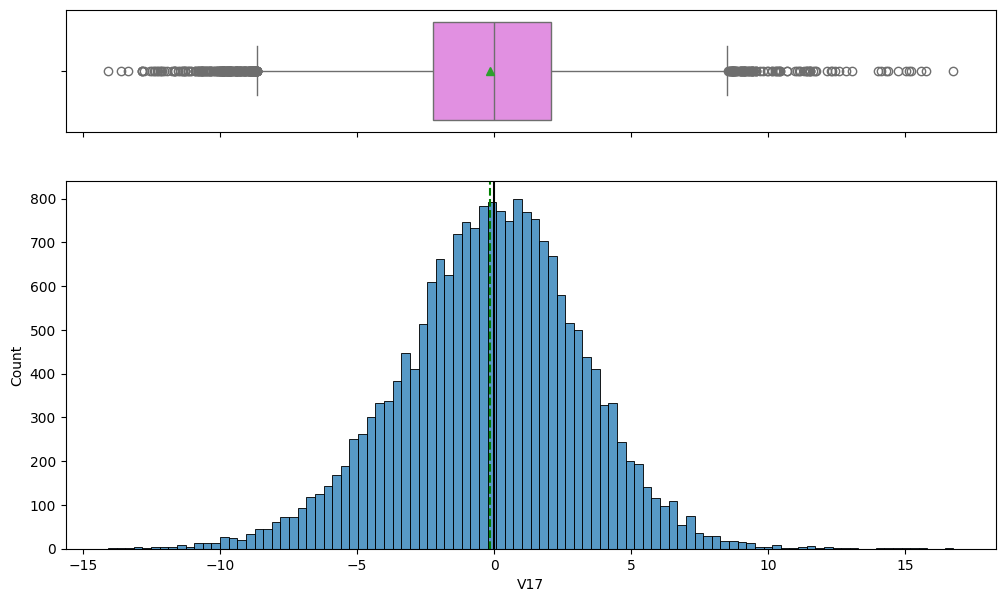

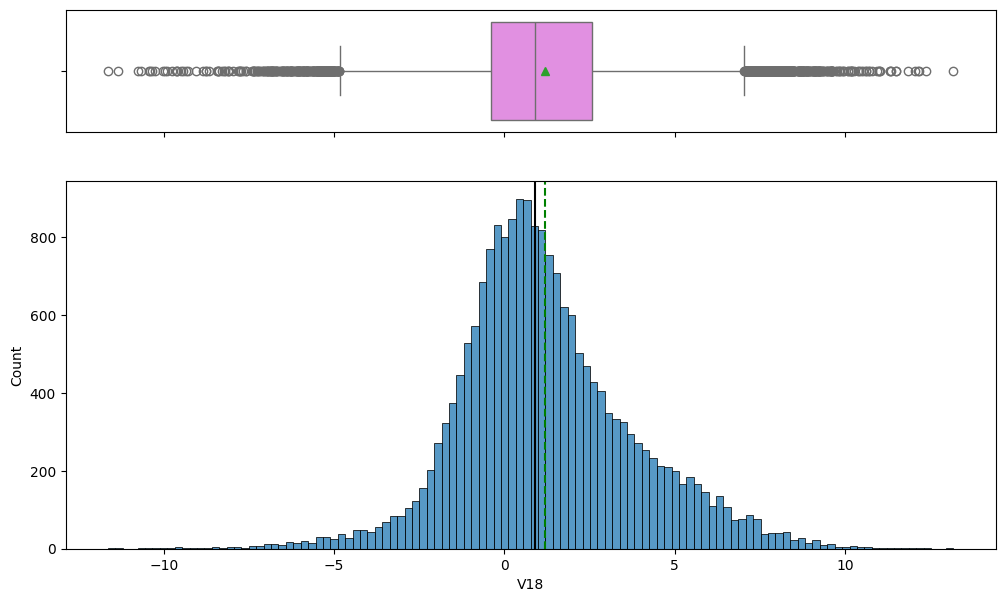

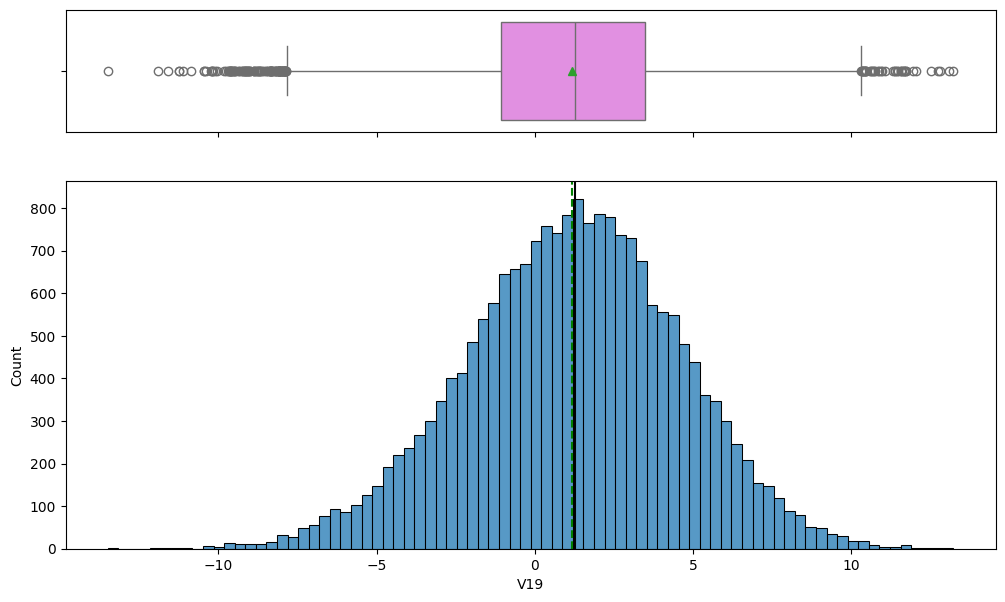

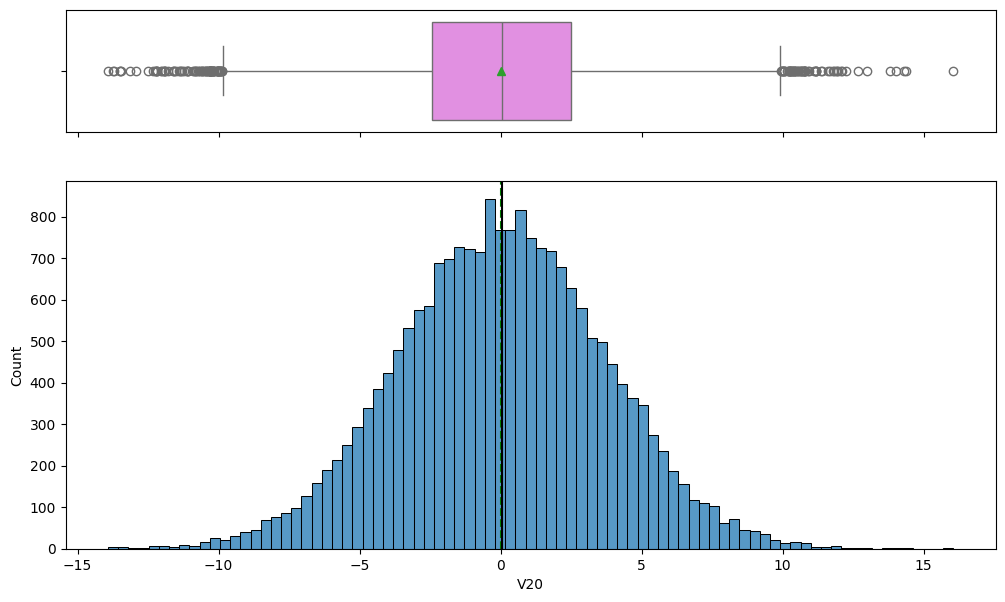

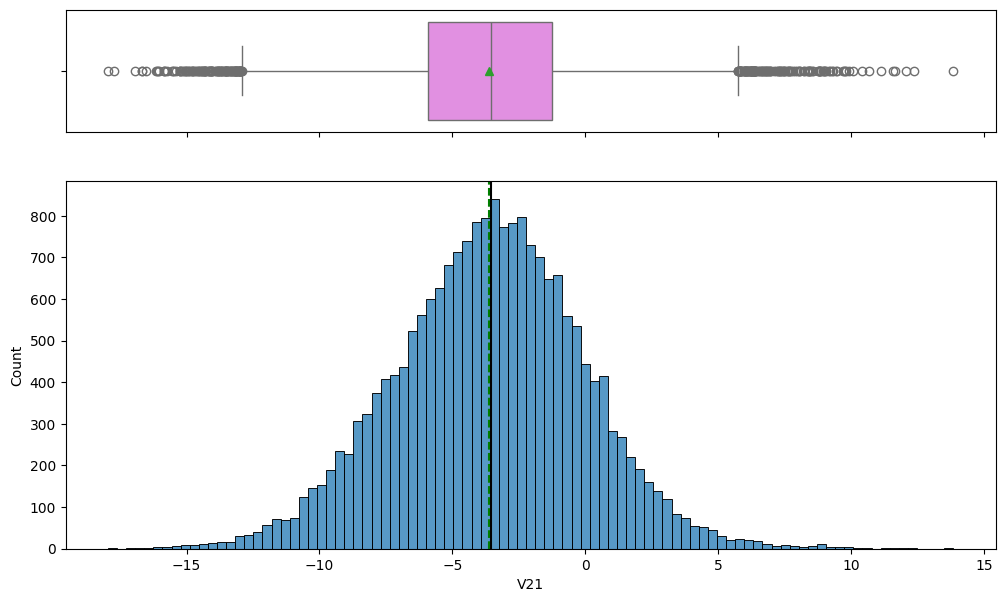

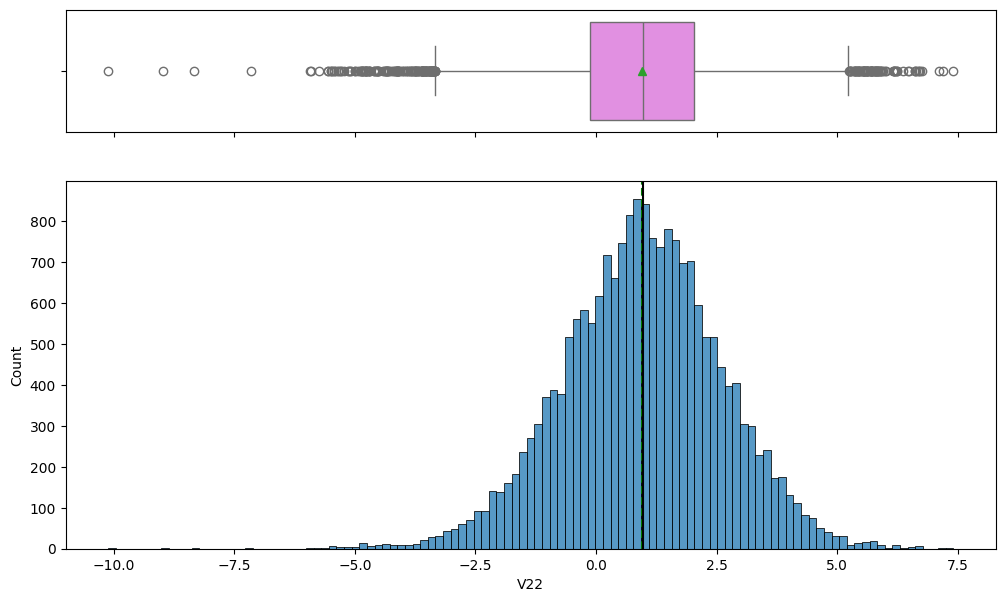

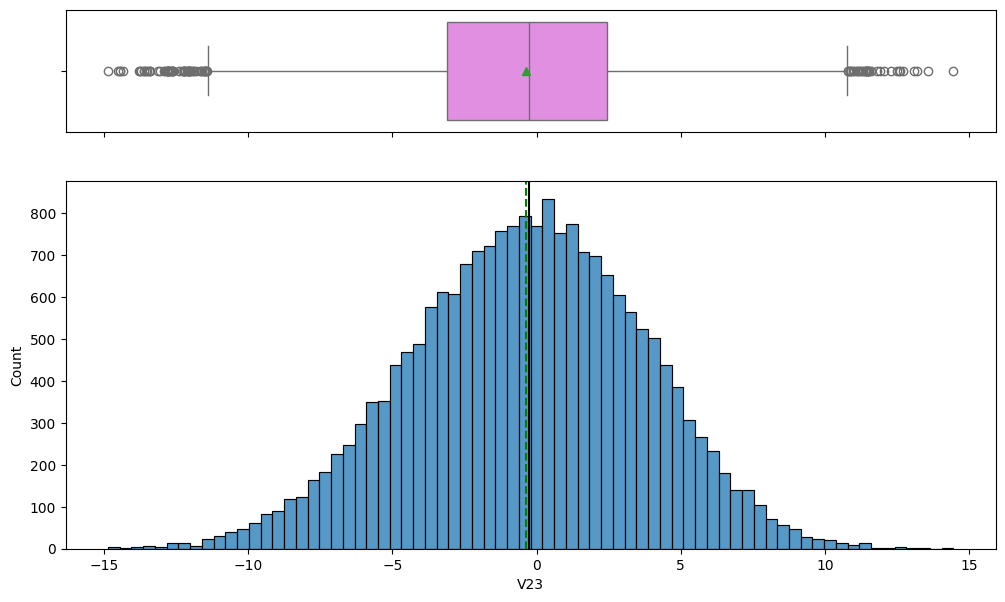

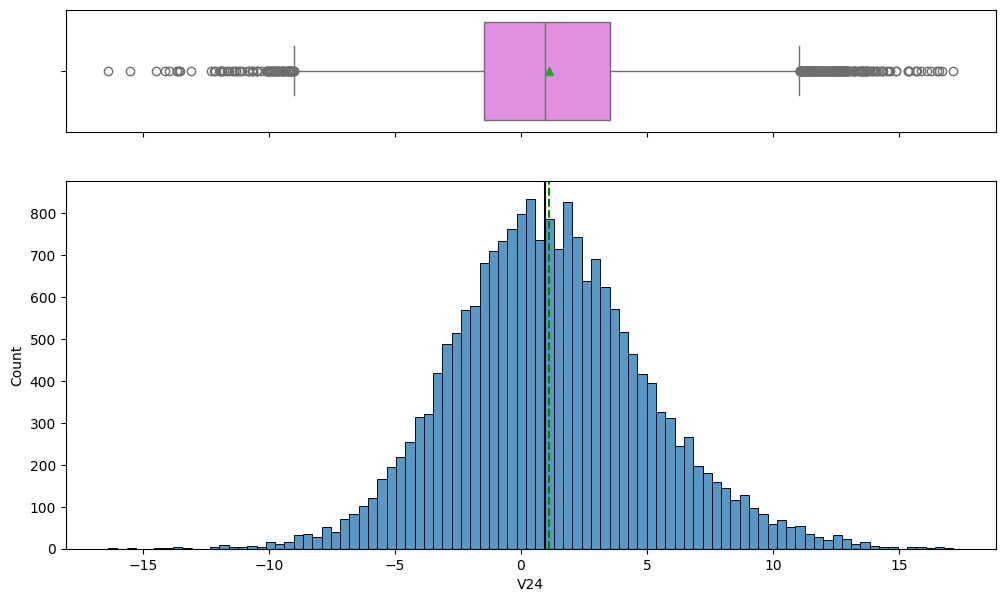

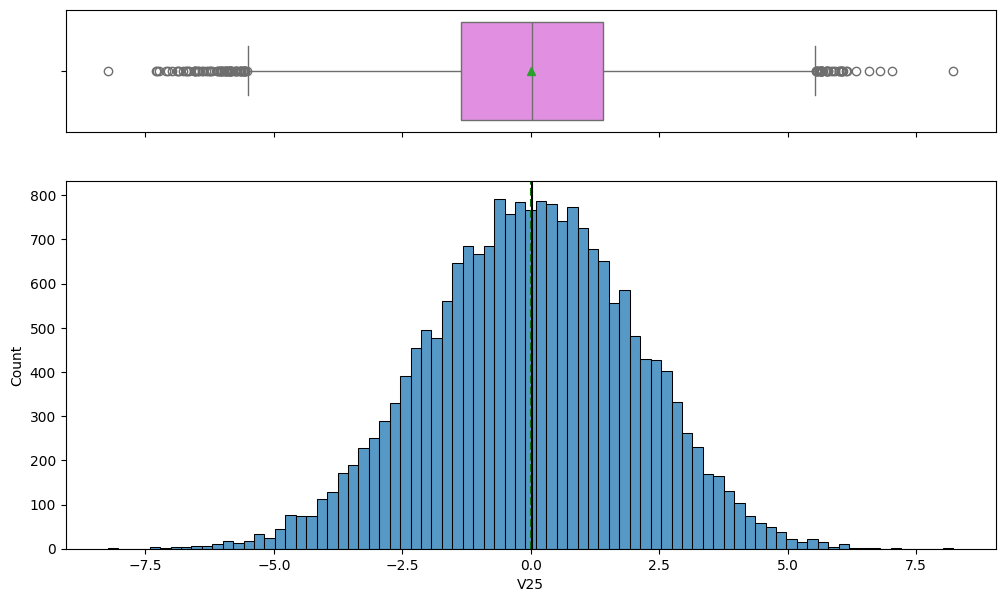

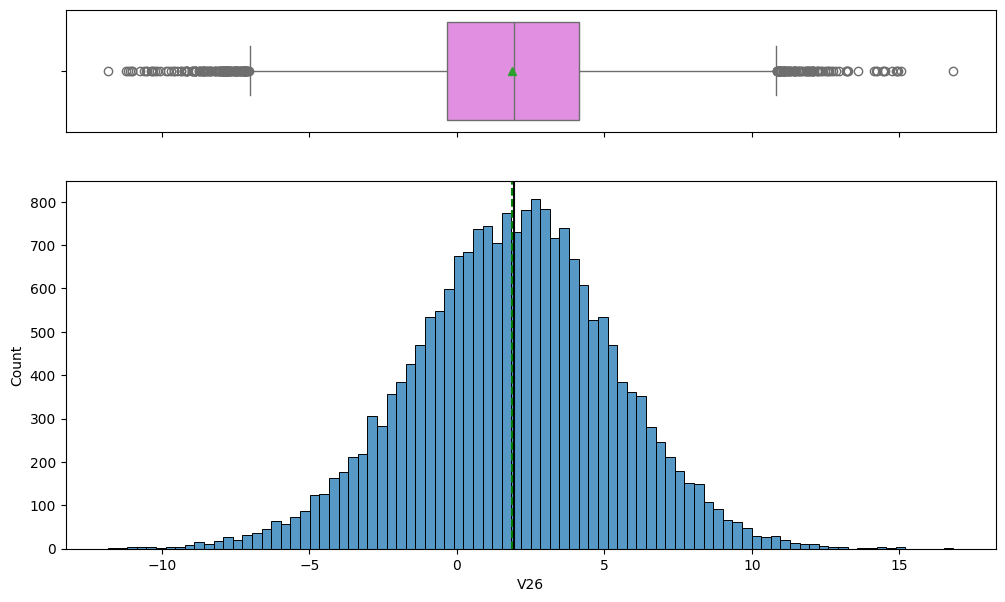

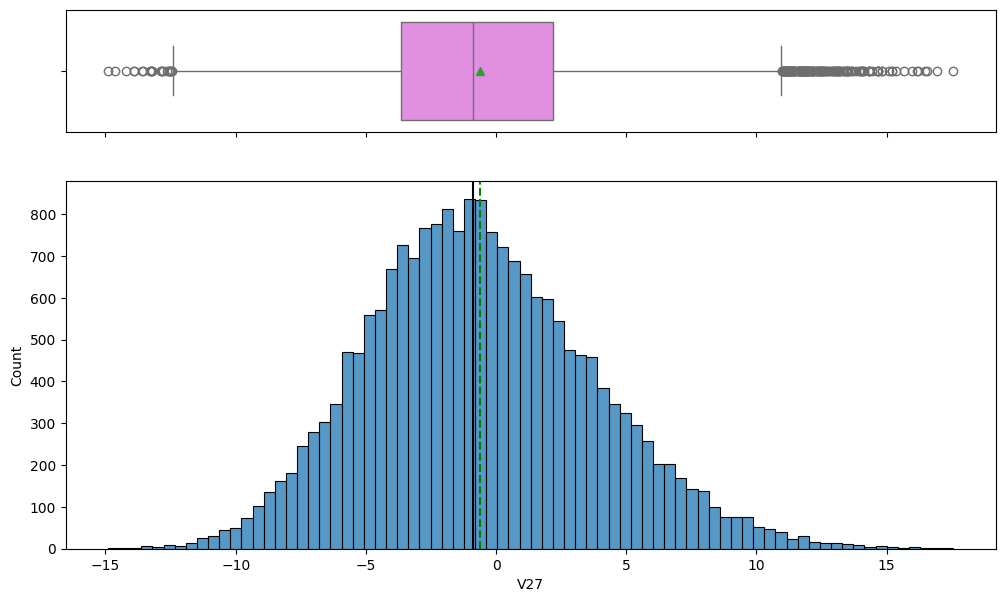

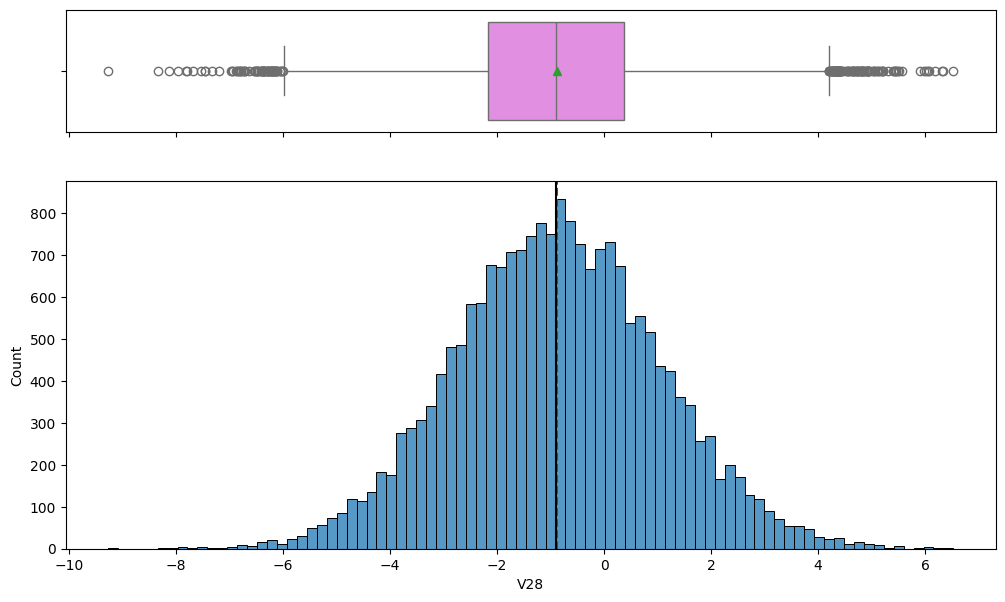

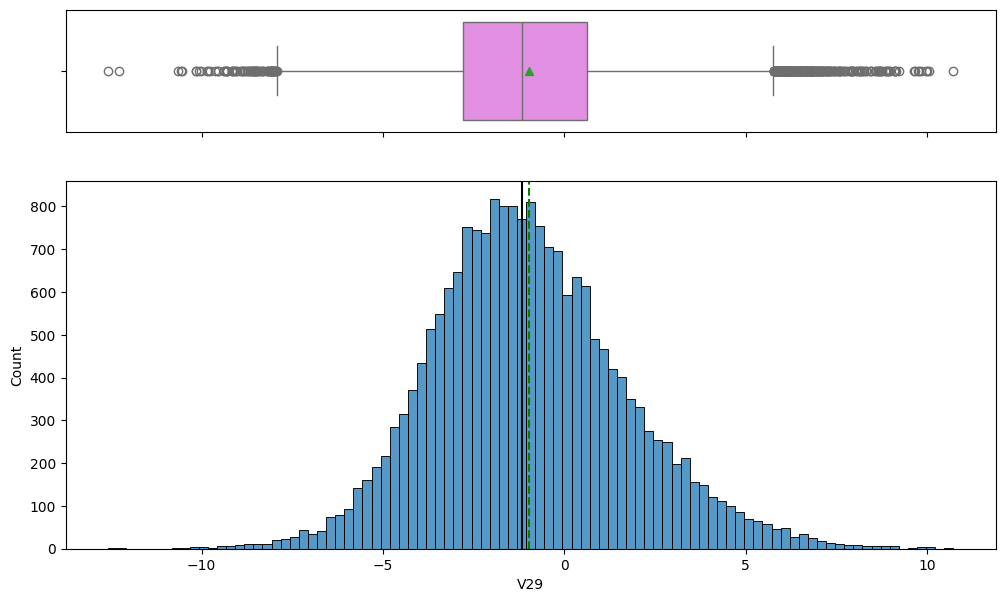

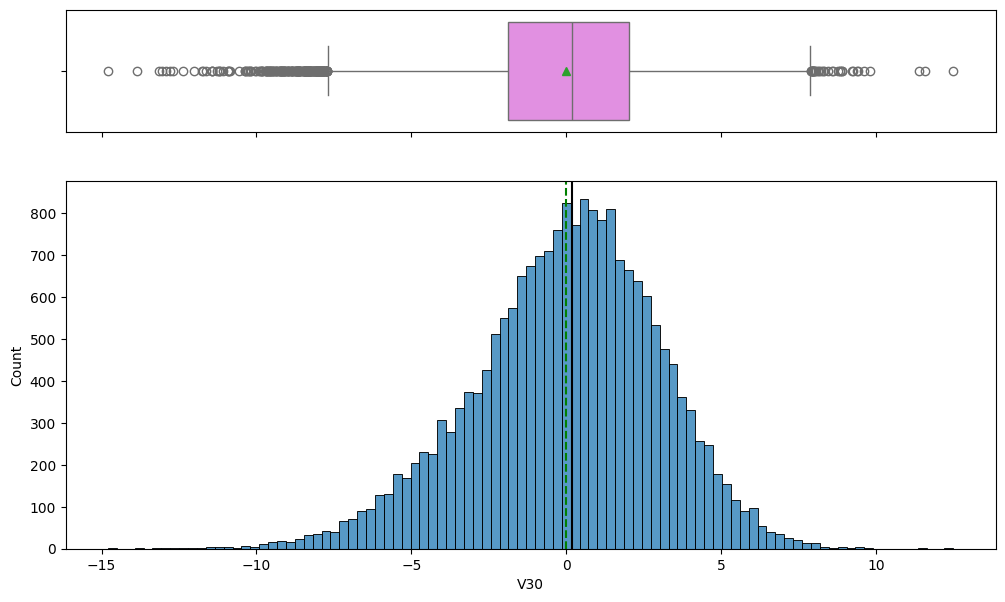

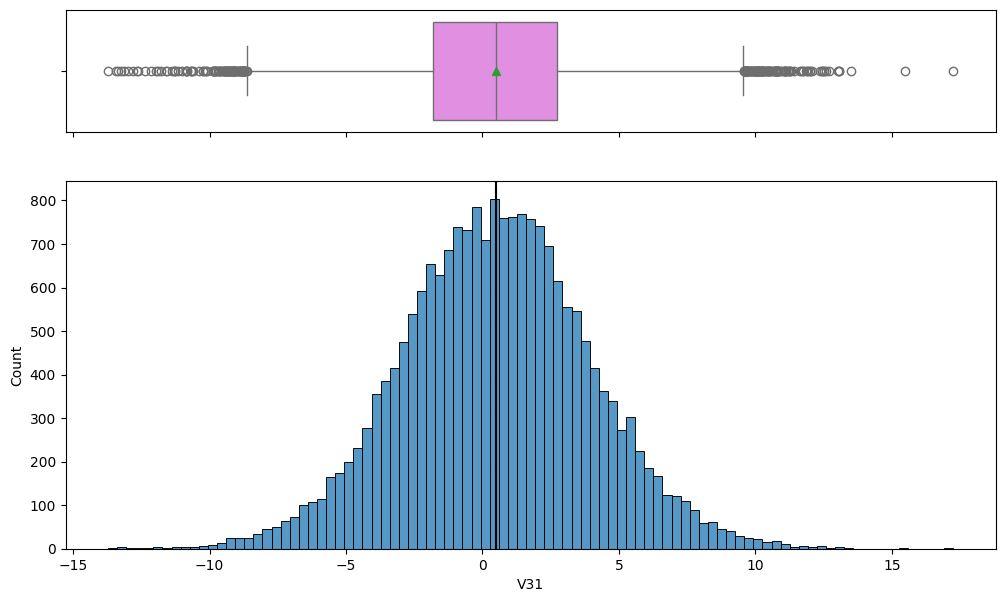

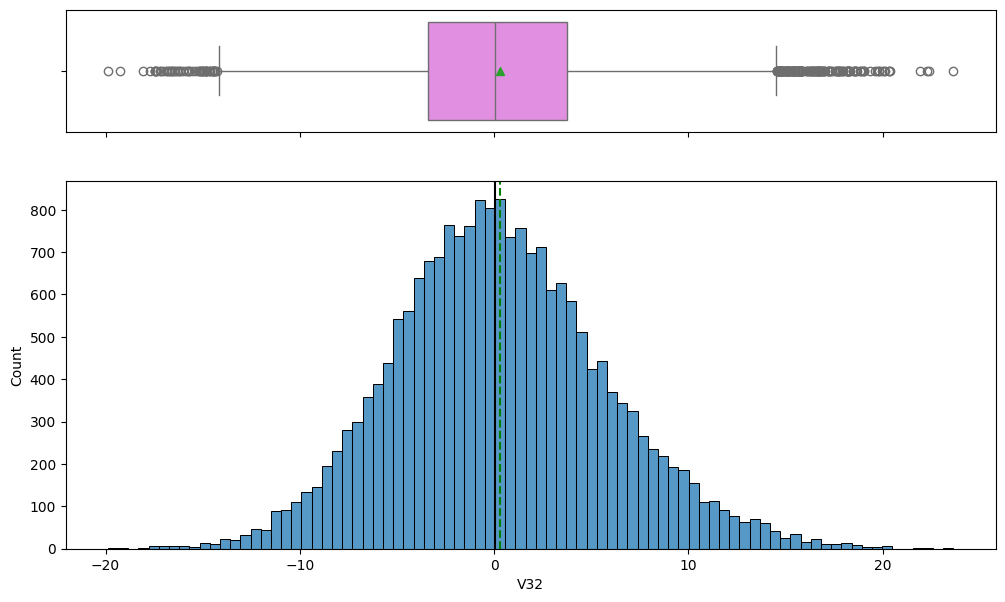

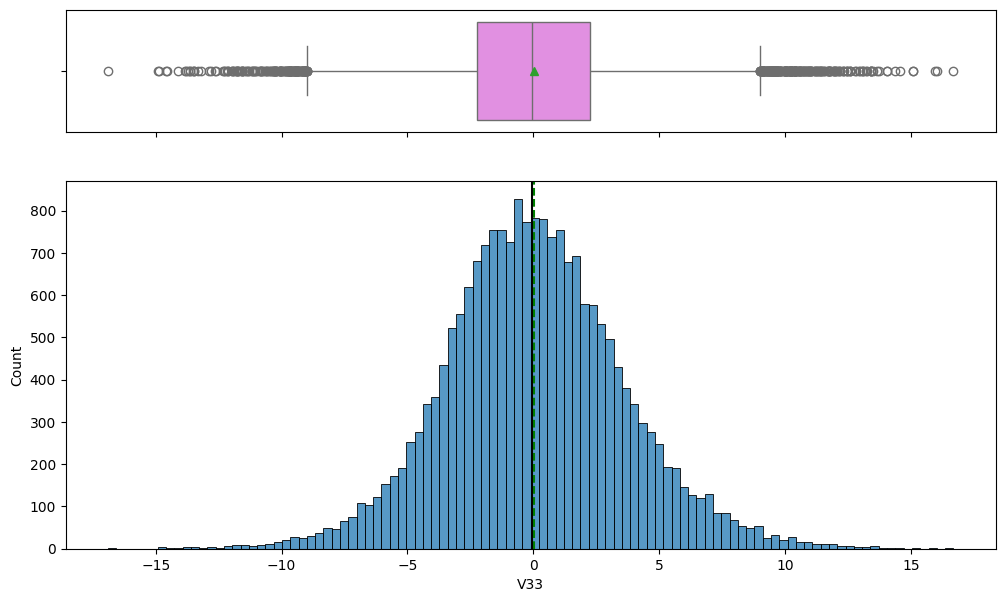

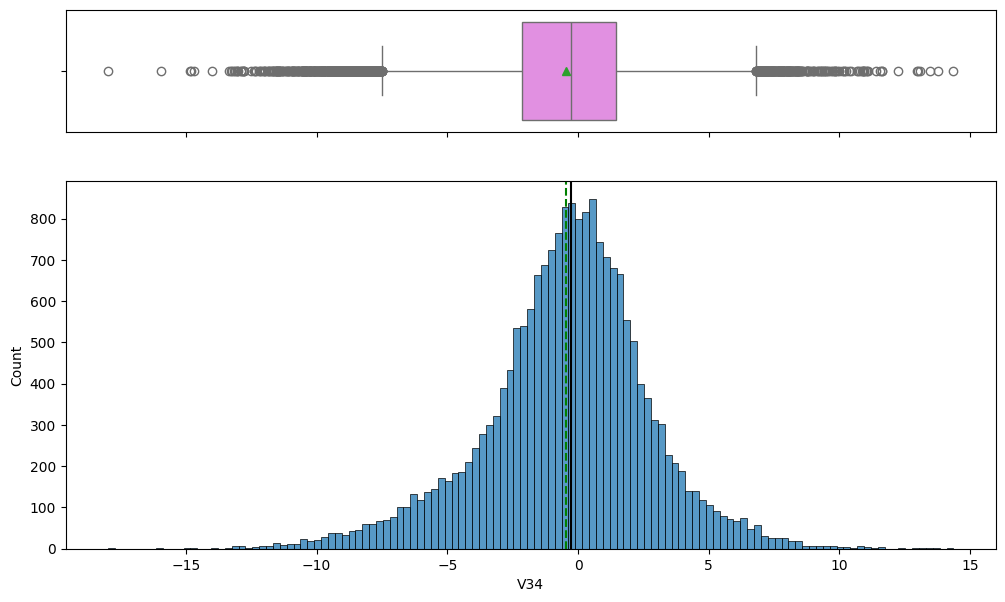

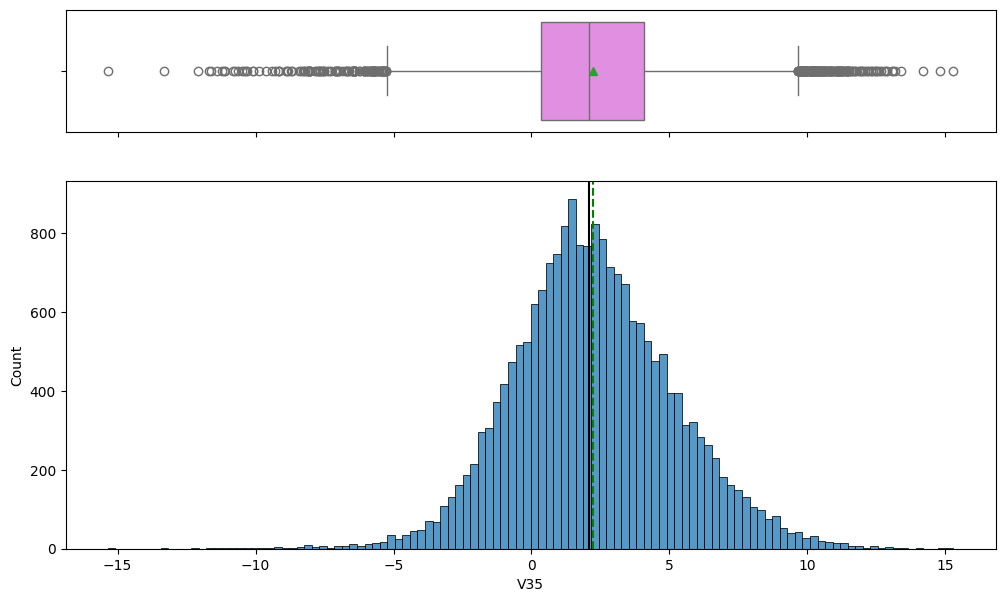

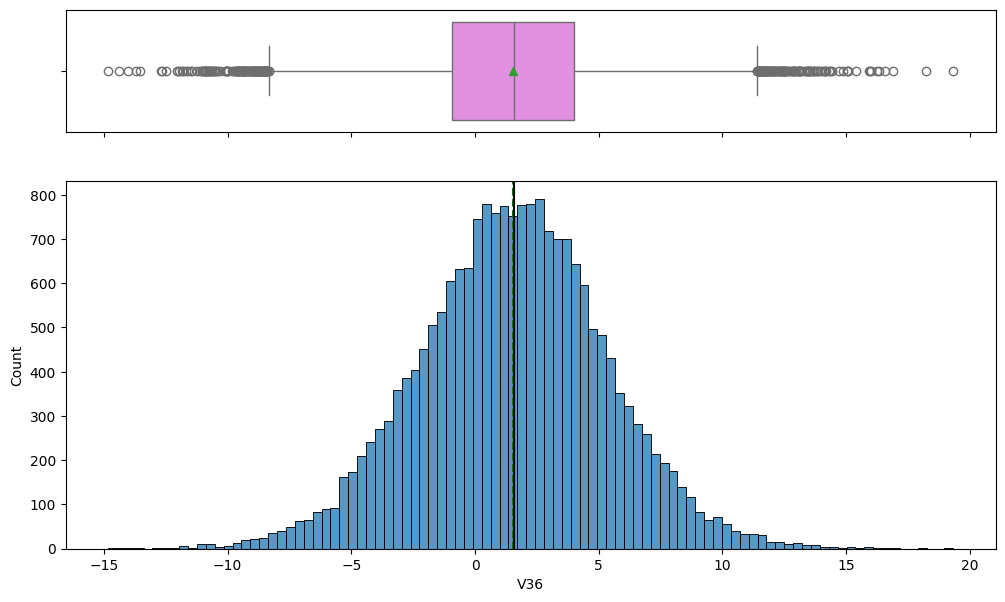

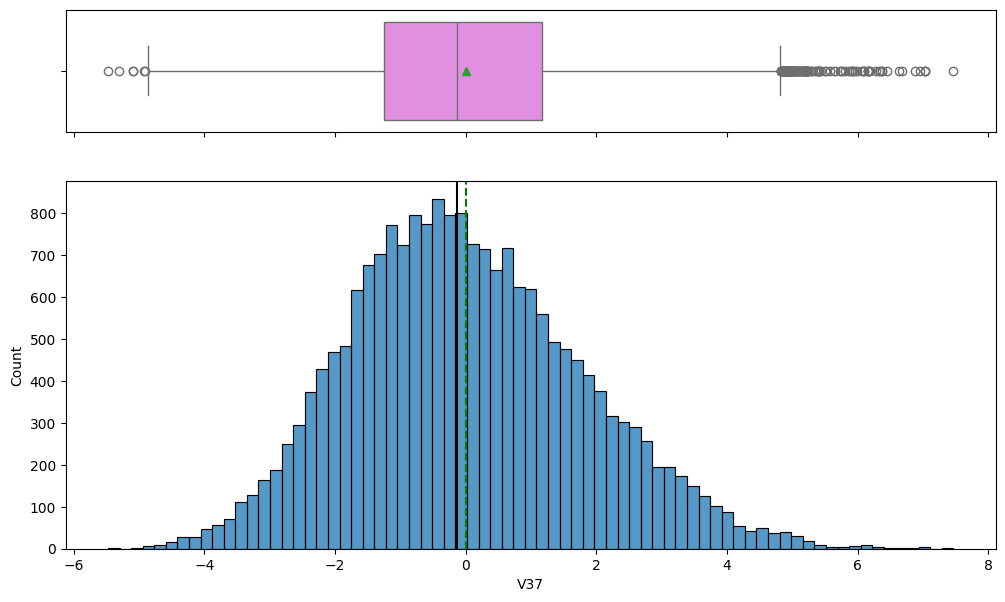

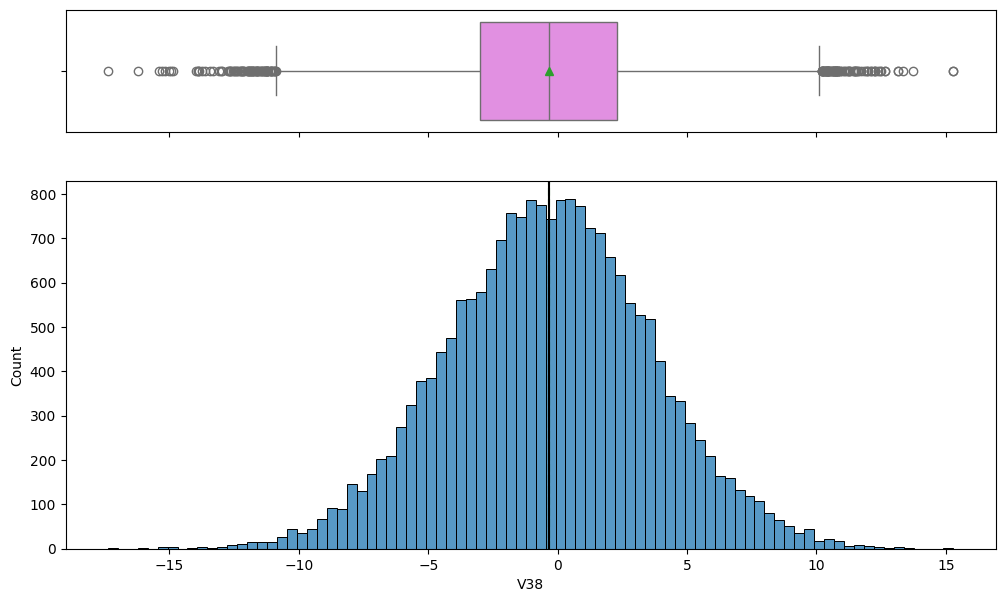

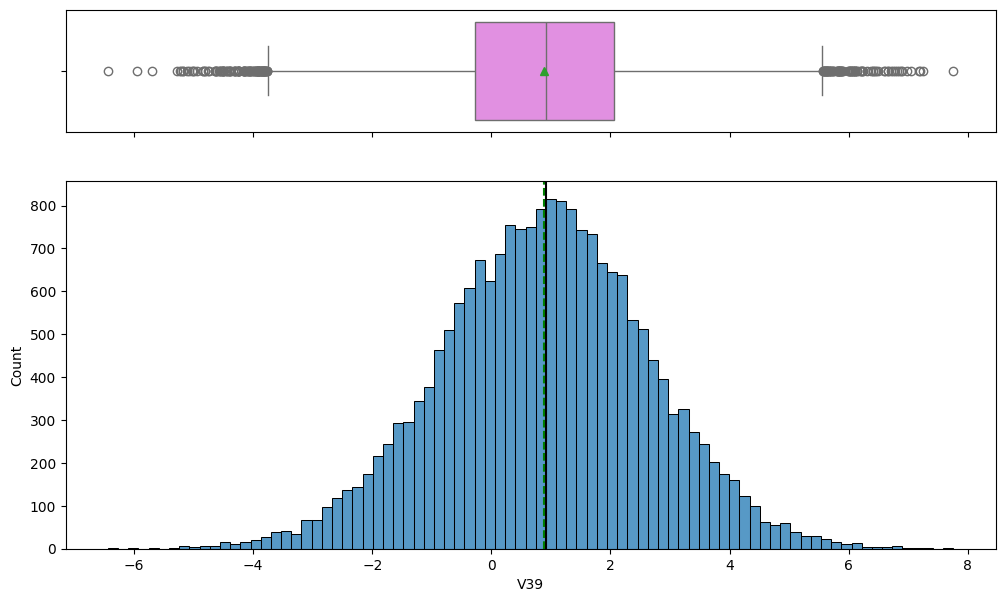

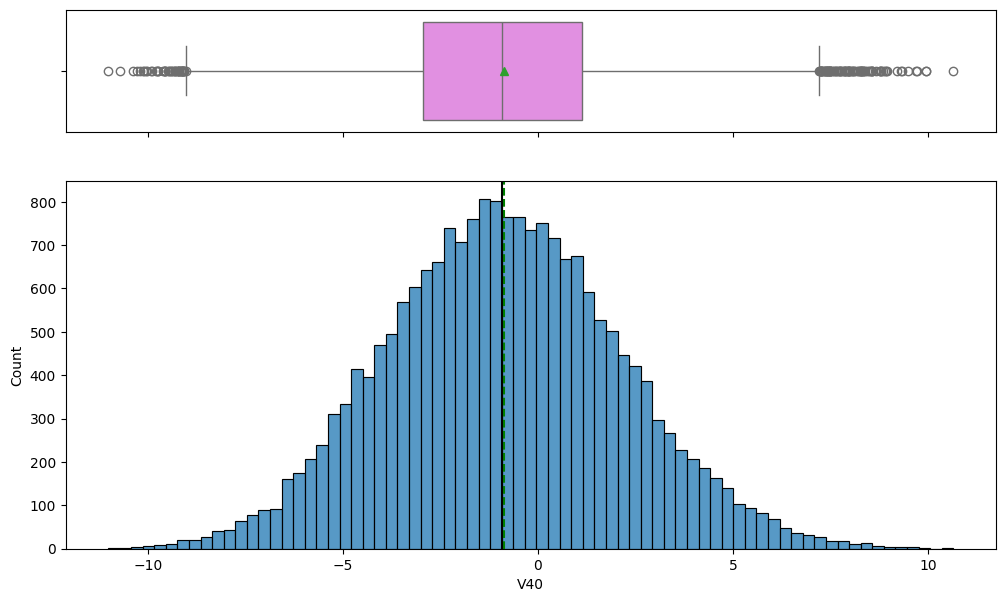

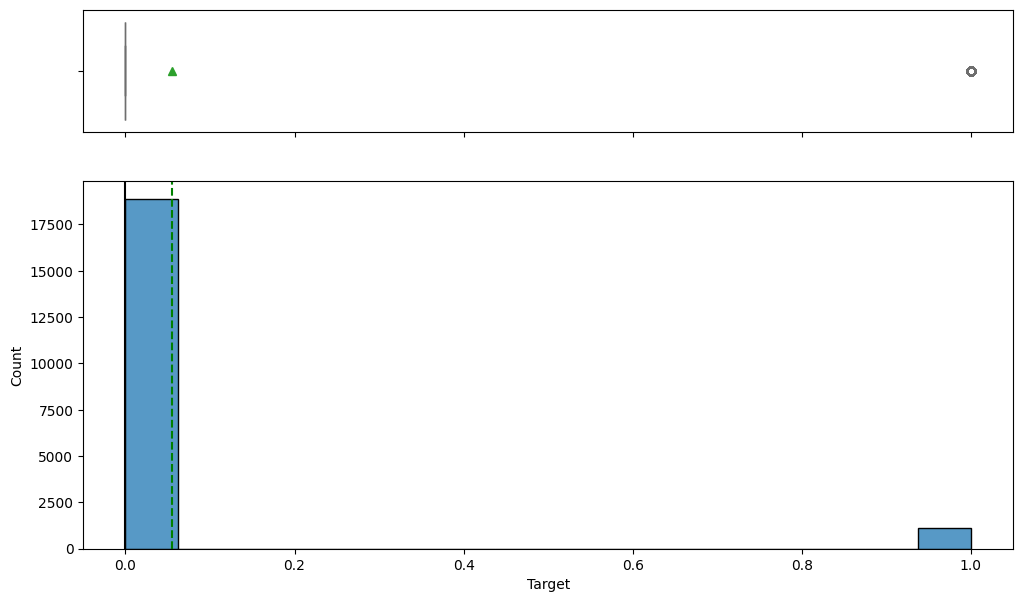

In [ ]:
# Using a histogram and boxplot to plot all these features
for feature in data.columns:
    histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None)

- *We observe that all the features are not heavily skewed in either direction, but have many outliers both to the left and right.*
- *We also see that most of the data is normalized with mean of 0.*


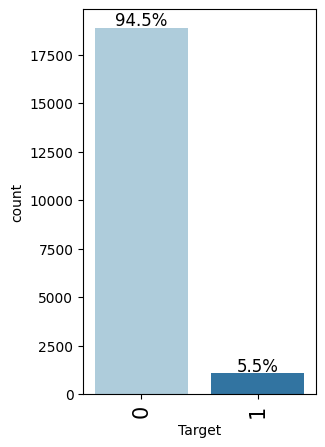

In [9]:
# Using labeled_barplot to see the distribution of the target variable
labeled_barplot(data, "Target", perc=True)

- *We see that the target variable is highly imbalanced with almost 95% of the data for value of 0 representing No failure.*
- *Thus it might be better to use class weights in the model building as it would have been ideal to get more data for 1 as we are more concerned about what conditions could result in Failure of the generators.*

## Bivariate Analysis

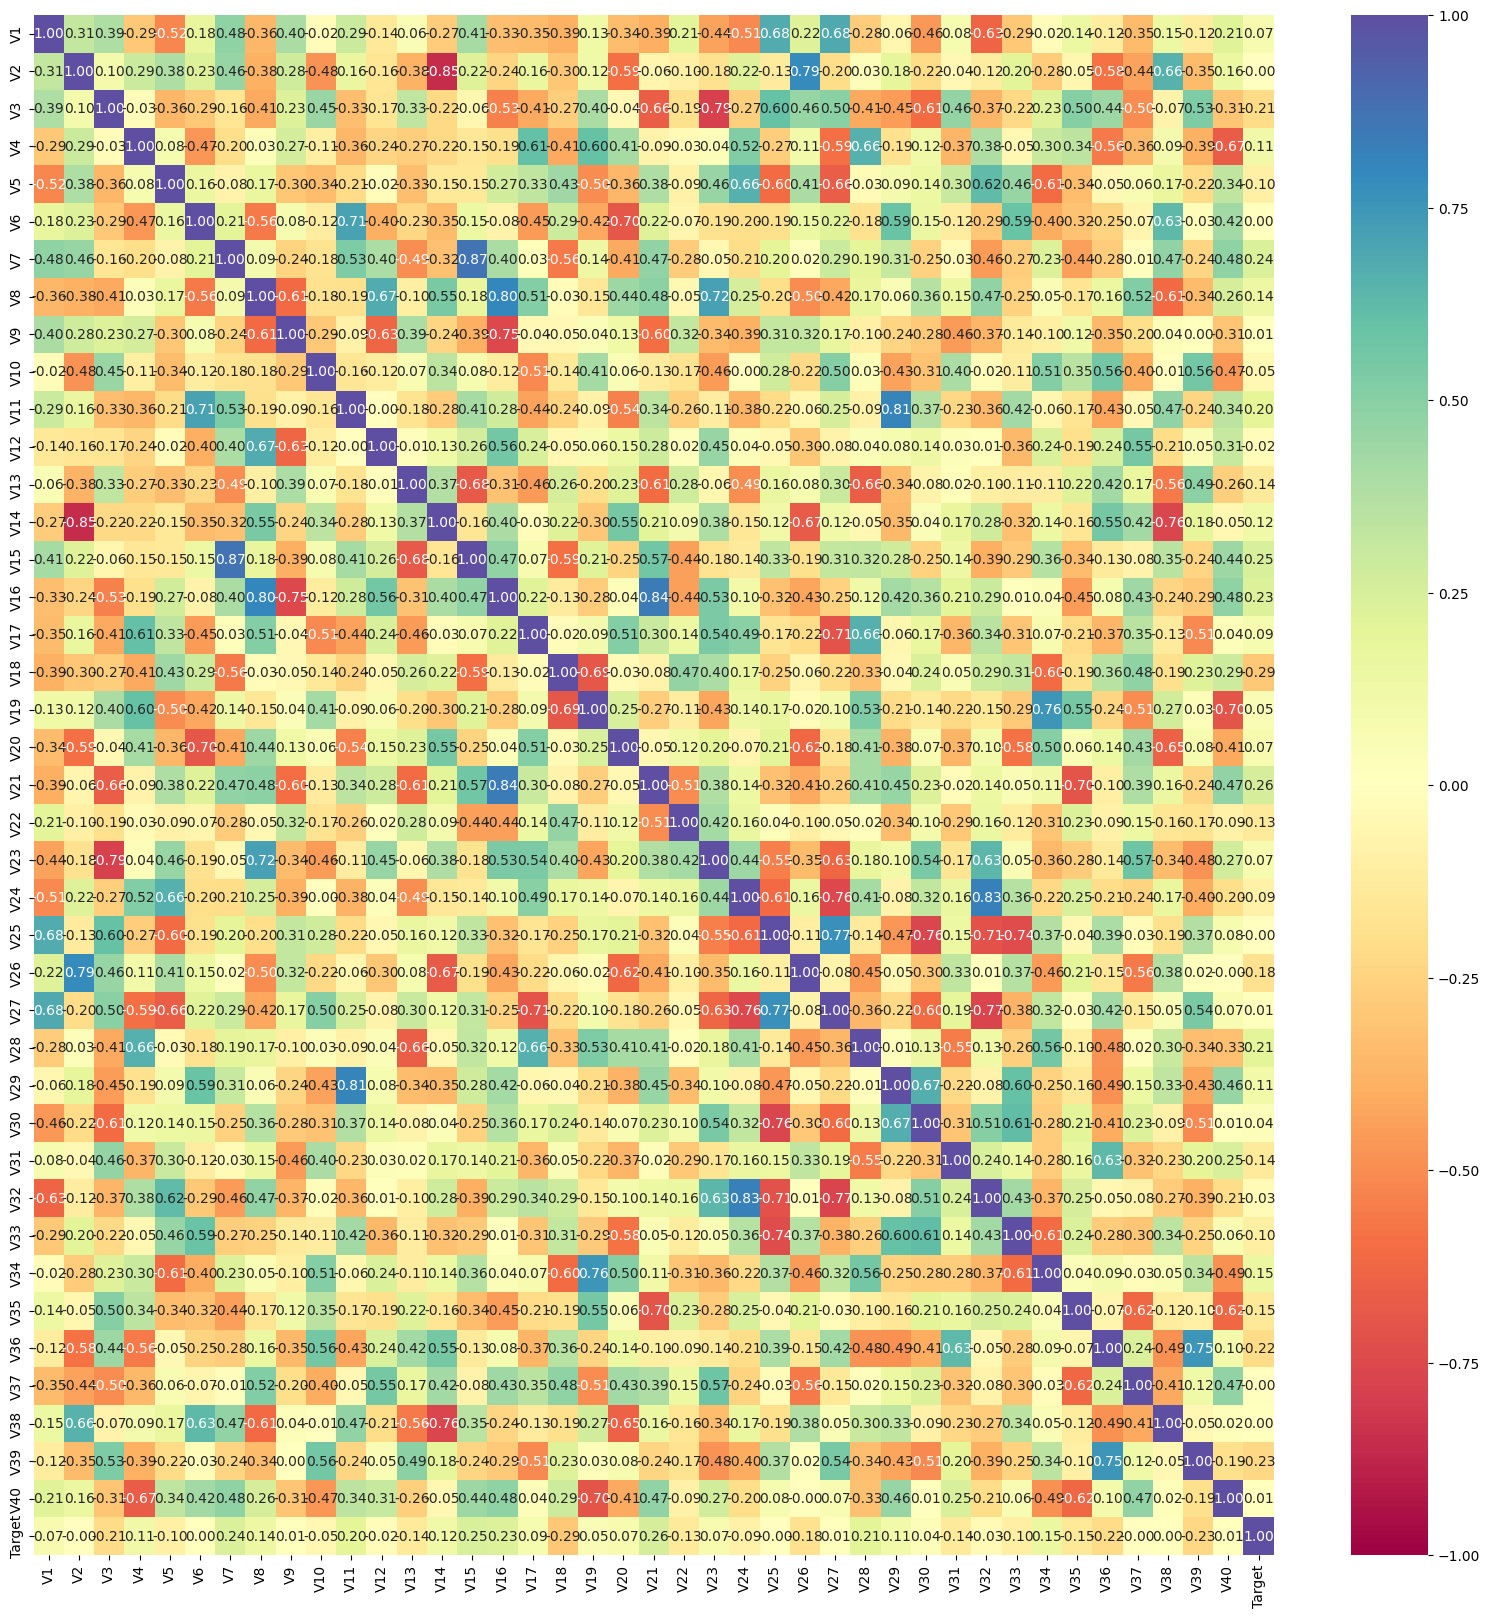

In [ ]:
# Using a heatmap to see the correlation between all the columns
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20, 20))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- *We see that some of the variables have high corelations to each other, for eg V38 and V14.*
-*But since we dont know what the features actually represent, it is difficult to understand what the corelations mean.*

# **Data Preprocessing**

## Splitting the dataset to train and validation sets

In [10]:
# Breaking data into X and y
X = data.drop(columns=["Target"], axis=1)
y = data["Target"]

# Using train_test_split to split the data into train and validation sets with
# validation size of 20 percent
# We already have a separate test set - so we dont have to split it further
# Using stratify to get the same proportion of target data values in both the sets

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Dividing test data into X_test and y_test
X_test = data_test.drop(columns=["Target"], axis=1)
y_test = data_test["Target"]

In [11]:
# Checking no of rows and cols for X_train and X_val
X_train.shape, X_val.shape, X_test.shape


((16000, 40), (4000, 40), (5000, 40))

## Missing value imputation

In [12]:
# We are doing missing value imputation after train val split to avoid data leakage.
# Missing value imputation
# We observed that the two features V1 and V2 have missing values
# Both of these features have many outliers

# So we will use the median to impute their values
# We will use SimpleImputer to impute these values

imputer = SimpleImputer(strategy="median")
X_train[["V1", "V2"]] = imputer.fit_transform(X_train[["V1", "V2"]])
X_val[["V1", "V2"]] = imputer.transform(X_val[["V1", "V2"]])
X_test[["V1", "V2"]] = imputer.transform(X_test[["V1", "V2"]])

In [13]:
# Check that there are no more null values in the data
print("Train Set\n",X_train.isna().sum(),"\n-------------")
print("Validation Set\n",X_val.isnull().sum(),"\n-------------")
print("Test Set\n",X_test.isnull().sum())

Train Set
 V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64 
-------------
Validation Set
 V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64 
-------------
Test Set
 V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    

- *We see that there are no more missing values in the train, validation and test sets.*

## Normalizing the Data

In [14]:
# We will normalize the train, test and validation data using StandardScaler for more efficient training
# and faster convergence.
transformer = StandardScaler()
X_train = transformer.fit_transform(X_train)
X_val = transformer.transform(X_val)
X_test = transformer.transform(X_test)

# **Model Building**

## Model Evaluation Criterion



- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

**Model can make wrong predictions as:**
1. Predicting that there is failure to the generator (1) when the generator actually has no failure - This is a false positive and could lead to inspection costs to verify failure.
2. Predicting that there is no failure (0) while the generator will fail - This is a false negative and will result in replacement costs later on.

**Which case is more important?**
* We have been given information that inspection costs are low compared to replacement or repair costs. So we are ok with false positives as it could just lead to inspection costs which are low. But we want to reduce false negatives as this could lead to replacement costs which are very high.
* So we should reduce false negatives and therefore we should try to increase recall score.
* So we will use recall score as the model evaluation criteria.

## Creating Utility functions for checking model performance

In [15]:
# Creating a utility function to plot results
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [16]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='binary')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

## Creating a class weights dictionary to give more importance to the Failure class of 1

In [17]:
# Since we saw that the target dependant variable is highly imbalanced with the 0 class having almost 95% of the data
# and we are mostly interested in the 1  (Failure) class.
# So we will use class weights giving 1 more weight than 0
# Calculate class weights for imbalanced dataset by dividing total number of rows of y_train with count of rows of 0 and 1
cw = (y_train.shape[0]) / np.bincount(y_train)

# Create a dictionary mapping class indices to their respective class weights
# Here 0 will get a smaller class weight since it has a larger count of rows and
# and dividing total number of rows with this larger number, will give a smaller weight for 0 compared to 1
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

- *We have a class weight ofr 18 for class 1 and 1.05 for class 0.*

## Creating a dataframe to store results of the models for comparison

In [21]:
#Defining the columns of the dataframe which are nothing but the hyper parameters and the metrics.
columns = ["# hidden layers","# neurons - hidden layer","activation function - hidden layer ","# epochs","batch size","optimizer","learning rate, momentum","weight initializer","regularization","train loss","validation loss","train Recall","validation Recall","time (secs)"]

#Creating a pandas dataframe.
results = pd.DataFrame(columns=columns)

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [22]:
# Setting number of epochs and batch size
epochs=25
batch_size=64

In [23]:
# Clearing session freeing up memory and resources
tf.keras.backend.clear_session()

In [24]:
# Creating first model with one hidden layer of 128 neurons and Relu activation function
# It has 1 output layer as this is a single classification problem with sigmoid as the activation function for the output layer
model_0 = Sequential()
model_0.add(Dense(128, activation="relu",input_dim=X_train.shape[1]))
model_0.add(Dense(1, activation="sigmoid"))
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Using SGD as the optimizer and binary_crossentropy for the loss function

# Default learning rate for SGD is .01
# Just storing these values to use in report later
learning_rate = 0.01

# Default momentum is 0
mom = 0.0

# Here we are using default learning rate and momentum, so we dont have to pass them when creating the optimizer
optimizer = tf.keras.optimizers.SGD()

model_0.compile(loss='binary_crossentropy', optimizer=optimizer)

In [26]:
# Fit the model with all our default values and no class weights
# Using start and end variables to capture the time it took to run fit method
start = time.time()
history = model_0.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3808 - val_loss: 0.2038
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1878 - val_loss: 0.1707
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1595 - val_loss: 0.1526
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1435 - val_loss: 0.1404
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1325 - val_loss: 0.1312
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1244 - val_loss: 0.1240
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1180 - val_loss: 0.1180
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1126 - val_loss: 0.1130
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1081 - val_loss: 0.1086
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1042 - val_loss: 0.1049
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1007 - val_loss: 0.1015
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

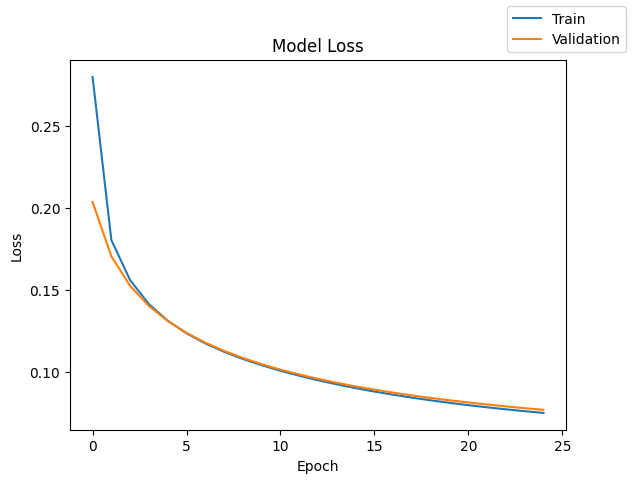

In [27]:
plot(history,'loss')

In [28]:
# Get the train and validation set recall values
model = model_0
model_0_train_perf = model_performance_classification(model, X_train, y_train)
model_0_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_0_train_perf["Recall"].values[0]
val_recall = model_0_val_perf["Recall"].values[0]

# Getting other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = [model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "-"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [29]:
results.loc[0] = [count_of_layers,[neuron_counts], [activation_functions], epochs, batch_size, optimizer, [learning_rate, mom], w_initializers,"-", train_loss, val_loss, train_recall, val_recall, round(end-start,2)]

In [30]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train Recall,validation Recall,time (secs)
0,1,[[128]],[[relu]],25,64,SGD,"[0.01, 0.0]",[GlorotUniform],-,0.075109,0.07699,0.720721,0.693694,21.63


- *The validation recall is a bit better than the training recall, showing there is no overfitting. Both the scores are very close to 1 which is very good.*
- *We see that uptill epoch 5, the loss reduced quickly and then the improvement reduced in further epochs.*
- *This could be because we are near a local minimum and further weight updates are less.*
- *We know that momentum will increase convergence by adding a fraction of the previous weights that were used.*
- *So we will add some momentum in the next model and see how it affects the results.*
- *We will also add one more layer to see if it can help in improving scores.*
- *We will also add the class weights we created earlier to see if that has any effect.*


# **Model Performance Improvement**

## Model 1

In [19]:
# Clearing session
tf.keras.backend.clear_session()

In [20]:
# Defining model 1 with one more hidden layer of 64 neurons with relu activation function
# Adding class weights and momentum also
model_1 = Sequential()
model_1.add(Dense(128 ,activation="relu",input_dim=X_train.shape[1]))
model_1.add(Dense(64,activation="relu"))
model_1.add(Dense(1,activation="sigmoid"))
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Using SGD as the optimizer with momentum of 0.6
mom = 0.6
optimizer = tf.keras.optimizers.SGD(momentum=mom)
model_1.compile(loss='binary_crossentropy', optimizer=optimizer)

In [32]:
# Fit the model with all the values defined above
# Using start and end variables to capture the time it took to run
# Also setting the class weights defined earlier
start = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight = cw_dict)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8606 - val_loss: 0.2975
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4991 - val_loss: 0.2389
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4288 - val_loss: 0.2177
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3898 - val_loss: 0.2008
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3620 - val_loss: 0.1964
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3426 - val_loss: 0.1934
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3265 - val_loss: 0.1881
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3138 - val_loss: 0.1827
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3037 - val_loss: 0.1823
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2950 - val_loss: 0.1820
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2865 - val_loss: 0.1771
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

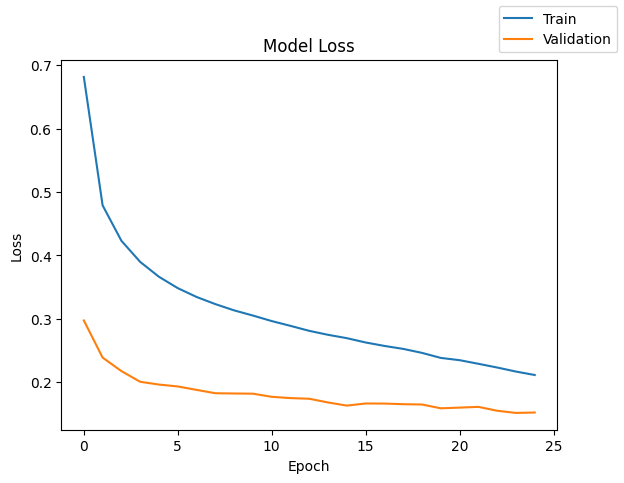

In [34]:
plot(history,'loss')

In [35]:
# Get the train and validation set recall values
model = model_1
model_1_train_perf = model_performance_classification(model, X_train, y_train)
model_1_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_1_train_perf["Recall"].values[0]
val_recall = model_1_val_perf["Recall"].values[0]

# and other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = [model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "-"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [36]:
results.loc[1] = [count_of_layers,[neuron_counts], [activation_functions], epochs, batch_size, optimizer, [learning_rate, mom], w_initializers,"-", train_loss, val_loss, train_recall, val_recall, round(end-start,2)]

In [37]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train Recall,validation Recall,time (secs)
0,1,[[128]],[[relu]],25,64,SGD,"[0.01, 0.0]",[GlorotUniform],-,0.075109,0.076990,0.720721,0.693694,21.63
1,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.01, 0.6]","[GlorotUniform, GlorotUniform]",-,0.211509,0.152331,0.958333,0.923423,30.46


- *We observe that the train and validation losses have increased which is not good as we are trying to get them to 0.*
- *We have lower train and validation recall scores compared to the previous model.*
- *We also notice that validation recall is lower than the train recall.*
- *This could be due to overfitting as the network is learning from the noise in the training data.*
- *We will try to reduce this overfitting by reducing the learning rate and also increase momentum to see if that improves the scores and reduces overfitting.*
- *The class weights have not helped in reducing loss or in improving the recall scores.*

## Model 2

In [38]:
# Clearing session
tf.keras.backend.clear_session()

In [39]:
# Defining model 2 with same values as model 1 but
# with an increase in momentum and a reduction in learning rate

model_2 = Sequential()
model_2.add(Dense(128 ,activation="relu",input_dim=X_train.shape[1]))
model_2.add(Dense(64,activation="relu"))
model_2.add(Dense(1,activation="sigmoid"))
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Using SGD as the optimizer with a reduced learning rate of .001
# Increasing momentum to 0.7
mom = 0.7
learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(momentum=mom, learning_rate=learning_rate)
model_2.compile(loss='binary_crossentropy', optimizer=optimizer)

In [41]:
# Fit the model with all the values defined above
# Using start and end variables to capture the time it took to run
start = time.time()
history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6336 - val_loss: 0.2564
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2354 - val_loss: 0.2103
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1981 - val_loss: 0.1883
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1782 - val_loss: 0.1733
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1643 - val_loss: 0.1622
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1536 - val_loss: 0.1534
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1451 - val_loss: 0.1461
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1380 - val_loss: 0.1399
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1321 - val_loss: 0.1346
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1269 - val_loss: 0.1299
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1225 - val_loss: 0.1256
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

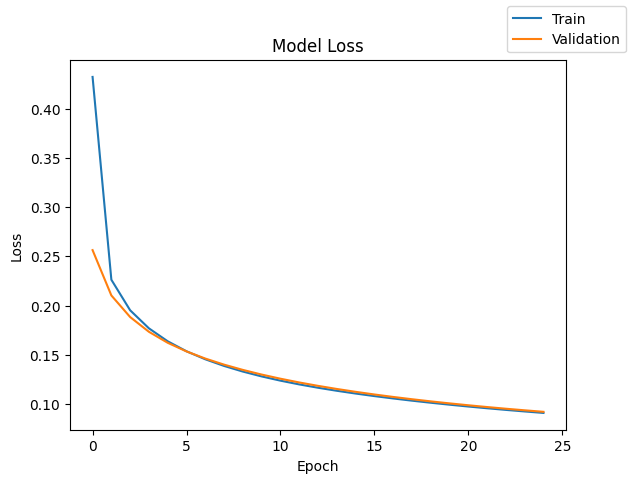

In [42]:
plot(history,'loss')

In [43]:
# Get the train and validation set recall values
model = model_2
model_2_train_perf = model_performance_classification(model, X_train, y_train)
model_2_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_2_train_perf["Recall"].values[0]
val_recall = model_2_val_perf["Recall"].values[0]

# and other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = [model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "-"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [44]:
results.loc[2] = [count_of_layers,[neuron_counts], [activation_functions], epochs, batch_size, optimizer, [learning_rate, mom], w_initializers,"-", train_loss, val_loss, train_recall, val_recall, round(end-start,2)]

In [45]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train Recall,validation Recall,time (secs)
0,1,[[128]],[[relu]],25,64,SGD,"[0.01, 0.0]",[GlorotUniform],-,0.075109,0.076990,0.720721,0.693694,21.63
1,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.01, 0.6]","[GlorotUniform, GlorotUniform]",-,0.211509,0.152331,0.958333,0.923423,30.46
2,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.001, 0.7]","[GlorotUniform, GlorotUniform]",-,0.090856,0.091982,0.629505,0.603604,28.88


- *We observe that this increase in momentum and reducing of the learning rate has improved our recall scores a bit compared to the previous model.*
- *We still see that the overfitting has also gone as we have a better validation recall score than train recall score.*
- *But the loss has increased again compared to previous model.*
- *In the next experiment, we will try increasing momentum to .9 and decrease leaning rate to .0001.*
- *We will also change activation function of a layer to see how that affects the results.*

## Model 3

In [46]:
# Clearing session
tf.keras.backend.clear_session()

In [47]:
# Defining model 3 with same values as model 2 but
# changing activation layer of second layer to tanh
# and increase momentum to .9 and reduce learning rate to .0001

model_3 = Sequential()
model_3.add(Dense(128 ,activation="relu",input_dim=X_train.shape[1]))
model_3.add(Dense(64,activation="tanh"))
model_3.add(Dense(1,activation="sigmoid"))
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Using SGD as the optimizer with a reduced learning rate of .0001
# Increasing momentum to 0.9
mom = 0.9
learning_rate = 0.0001
optimizer = tf.keras.optimizers.SGD(momentum=mom, learning_rate=learning_rate)
model_3.compile(loss='binary_crossentropy', optimizer=optimizer)

In [49]:
# Fit the model
start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4834 - val_loss: 0.3099
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2856 - val_loss: 0.2499
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2382 - val_loss: 0.2268
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2182 - val_loss: 0.2142
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2066 - val_loss: 0.2056
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1985 - val_loss: 0.1989
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1920 - val_loss: 0.1933
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1865 - val_loss: 0.1884
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1816 - val_loss: 0.1840
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1772 - val_loss: 0.1799
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1732 - val_loss: 0.1762
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

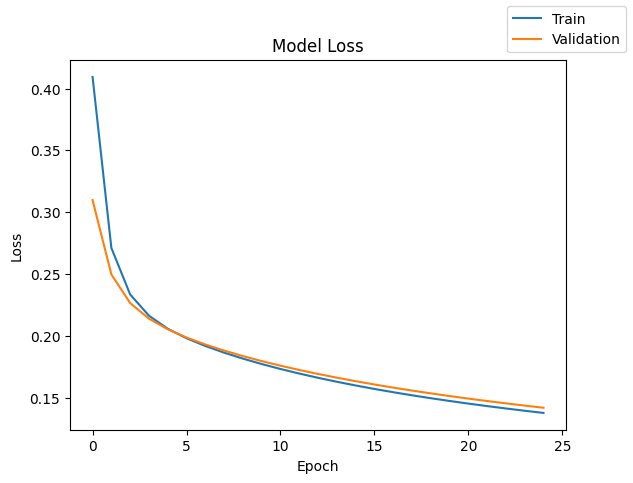

In [50]:
plot(history,'loss')

In [51]:
# Get the train and validation set recall values
model = model_3
model_3_train_perf = model_performance_classification(model, X_train, y_train)
model_3_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_3_train_perf["Recall"].values[0]
val_recall = model_3_val_perf["Recall"].values[0]

# and other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = [model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "-"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [52]:
results.loc[3] = [count_of_layers,[neuron_counts], [activation_functions], epochs, batch_size, optimizer, [learning_rate, mom], w_initializers,"-", train_loss, val_loss, train_recall, val_recall, round(end-start,2)]

In [53]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train Recall,validation Recall,time (secs)
0,1,[[128]],[[relu]],25,64,SGD,"[0.01, 0.0]",[GlorotUniform],-,0.075109,0.076990,0.720721,0.693694,21.63
1,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.01, 0.6]","[GlorotUniform, GlorotUniform]",-,0.211509,0.152331,0.958333,0.923423,30.46
2,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.001, 0.7]","[GlorotUniform, GlorotUniform]",-,0.090856,0.091982,0.629505,0.603604,28.88
3,2,"[[128, 64]]","[[relu, tanh]]",25,64,SGD,"[0.0001, 0.9]","[GlorotUniform, GlorotUniform]",-,0.138041,0.142223,0.262387,0.243243,30.92


- *We notice that our train and validation losses are still increasing and our recall scores have decreased from the previous model.*
- *Increasing momentum, decreasing learning rate and change activation of a layer to tanh does not seem to have helped much in improving scores.*
- *We have reduced overfitting somewhat so that is good.*
- *Next let us try experimenting with the Adam optimizer and check the results with that.*
- *We will also add one more layer to our model with 64 neurons to experiment.*

## Model 4

In [54]:
# Clearing session
tf.keras.backend.clear_session()

In [55]:
# Defining model 4 with same values as model 3 but
# adding one more layer with 64 neurons and relu activation
# and using Adam optimizer

model_4 = Sequential()
model_4.add(Dense(128 ,activation="relu",input_dim=X_train.shape[1]))
model_4.add(Dense(64,activation="relu"))
model_4.add(Dense(64,activation="relu"))
model_4.add(Dense(1,activation="sigmoid"))
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Using Adam as the optimizer with default learning rate
# Since Adam does not have a momentum parameter, leaving it as -
mom = "-"

# Setting the default learning rate of Adam for the report
learning_rate = 0.001

# Using default learning rate of Adam
optimizer = tf.keras.optimizers.Adam()
model_4.compile(loss='binary_crossentropy', optimizer=optimizer)

In [57]:
# Fit the model
# with all the defined values
start = time.time()
history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2148 - val_loss: 0.0741
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0631 - val_loss: 0.0541
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0493 - val_loss: 0.0494
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0434 - val_loss: 0.0472
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0395 - val_loss: 0.0448
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0376 - val_loss: 0.0437
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0357 - val_loss: 0.0453
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0347 - val_loss: 0.0422
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0325 - val_loss: 0.0463
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0318 - val_loss: 0.0500
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0309 - val_loss: 0.0476
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

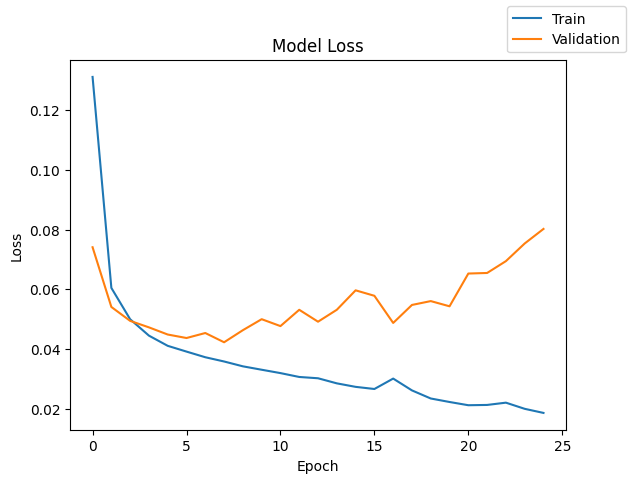

In [58]:
# Plot of loss function against epoch
plot(history,'loss')

In [59]:
# Get the train and validation set recall values
model = model_4
model_4_train_perf = model_performance_classification(model, X_train, y_train)
model_4_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_4_train_perf["Recall"].values[0]
val_recall = model_4_val_perf["Recall"].values[0]

# and other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = [model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "-"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [60]:
results.loc[4] = [count_of_layers,[neuron_counts], [activation_functions], epochs, batch_size, optimizer, [learning_rate, mom], w_initializers,"-", train_loss, val_loss, train_recall, val_recall, round(end-start,2)]

In [61]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train Recall,validation Recall,time (secs)
0,1,[[128]],[[relu]],25,64,SGD,"[0.01, 0.0]",[GlorotUniform],-,0.075109,0.076990,0.720721,0.693694,21.63
1,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.01, 0.6]","[GlorotUniform, GlorotUniform]",-,0.211509,0.152331,0.958333,0.923423,30.46
2,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.001, 0.7]","[GlorotUniform, GlorotUniform]",-,0.090856,0.091982,0.629505,0.603604,28.88
3,2,"[[128, 64]]","[[relu, tanh]]",25,64,SGD,"[0.0001, 0.9]","[GlorotUniform, GlorotUniform]",-,0.138041,0.142223,0.262387,0.243243,30.92
4,3,"[[128, 64, 64]]","[[relu, relu, relu]]",25,64,adam,"[0.001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]",-,0.018554,0.080206,0.938063,0.914414,31.68


- *Using the Adam optimizer and adding one more layer, we see that slight amount of overfitting has returned.*
- *We see the train and validation loss values are much better compared to previous model.*
- *We also see oscillations increasing after the 15th epoch from the plot of the loss function.*
- *Our results have not improved compared to the previous model.*
- *We will start experimenting with Adam by reducing the learning rate to see if that can help in reducing the oscillations and the overfitting.*

## Model 5

In [62]:
# Clearing session
tf.keras.backend.clear_session()

In [63]:
# Defining model 5 with same values as model 4 but
# reducing learning rate  for Adam optimizer

model_5 = Sequential()
model_5.add(Dense(128 ,activation="relu",input_dim=X_train.shape[1]))
model_5.add(Dense(64,activation="relu"))
model_5.add(Dense(64,activation="relu"))
model_5.add(Dense(1,activation="sigmoid"))
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Using Adam as the optimizer with learning rate of .0001
# Since Adam does not have a momentum parameter, leaving it as -
mom = "-"

learning_rate = 0.0001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_5.compile(loss='binary_crossentropy', optimizer=optimizer)

In [65]:
# Fit the model
# with all the defined values

start = time.time()
history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3823 - val_loss: 0.1863
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1627 - val_loss: 0.1328
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1191 - val_loss: 0.1044
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0959 - val_loss: 0.0878
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0816 - val_loss: 0.0772
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0720 - val_loss: 0.0698
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0651 - val_loss: 0.0643
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0599 - val_loss: 0.0603
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0560 - val_loss: 0.0572
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0528 - val_loss: 0.0547
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0503 - val_loss: 0.0527
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

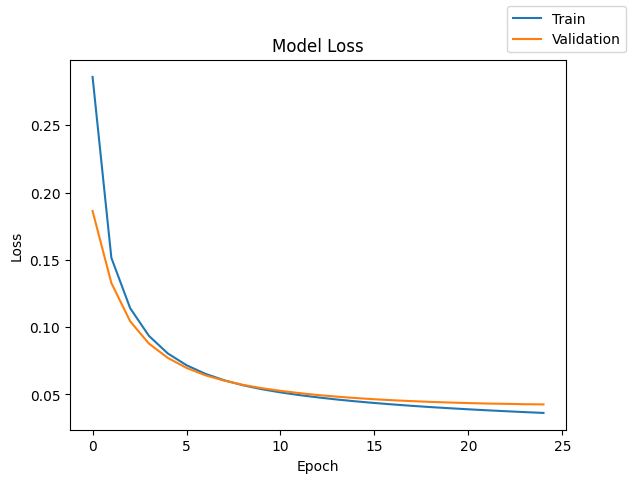

In [66]:
# Plot of loss function against epoch
plot(history,'loss')

In [67]:
# Get the train and validation set recall values
model = model_5
model_5_train_perf = model_performance_classification(model, X_train, y_train)
model_5_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_5_train_perf["Recall"].values[0]
val_recall = model_5_val_perf["Recall"].values[0]

# and other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = [model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "-"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [68]:
results.loc[5] = [count_of_layers,[neuron_counts], [activation_functions], epochs, batch_size, optimizer, [learning_rate, mom], w_initializers,"-", train_loss, val_loss, train_recall, val_recall, round(end-start,2)]

In [69]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train Recall,validation Recall,time (secs)
0,1,[[128]],[[relu]],25,64,SGD,"[0.01, 0.0]",[GlorotUniform],-,0.075109,0.076990,0.720721,0.693694,21.63
1,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.01, 0.6]","[GlorotUniform, GlorotUniform]",-,0.211509,0.152331,0.958333,0.923423,30.46
2,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.001, 0.7]","[GlorotUniform, GlorotUniform]",-,0.090856,0.091982,0.629505,0.603604,28.88
3,2,"[[128, 64]]","[[relu, tanh]]",25,64,SGD,"[0.0001, 0.9]","[GlorotUniform, GlorotUniform]",-,0.138041,0.142223,0.262387,0.243243,30.92
4,3,"[[128, 64, 64]]","[[relu, relu, relu]]",25,64,adam,"[0.001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]",-,0.018554,0.080206,0.938063,0.914414,31.68
5,3,"[[128, 64, 64]]","[[relu, relu, relu]]",25,64,adam,"[0.0001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]",-,0.036305,0.042635,0.889640,0.900901,34.35


- *We see that we have reduced the oscillations as well as the overfitting.*
- *We have improved train and validation recall scores compared to previous model.*
- *We notic that the training loss has increased.*
- *We will next try some dropouts for some of the layers to see if we can improve on our recall scores.*

## Model 6

In [70]:
# Clearing session
tf.keras.backend.clear_session()

In [71]:
# Defining model 6 with same values as model 5 but
# with dropout rates for the layers
# Using 4%, 2% and 2% respectively for the hidden layers

model_6 = Sequential()
model_6.add(Dense(128 ,activation="relu",input_dim=X_train.shape[1]))
model_6.add(Dropout(0.4))
model_6.add(Dense(64,activation="relu"))
model_6.add(Dropout(0.2))
model_6.add(Dense(64,activation="relu"))
model_6.add(Dropout(0.2))
model_6.add(Dense(1,activation="sigmoid"))
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Using Adam as the optimizer with learning rate of .0001 as we did in model 5
# Since Adam does not have a momentum parameter, leaving it as -
mom = "-"
learning_rate = 0.0001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_6.compile(loss='binary_crossentropy', optimizer=optimizer)

In [73]:
# Fit the model
# with all the defined values

start = time.time()
history = model_6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.3911 - val_loss: 0.6039
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0528 - val_loss: 0.5128
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9365 - val_loss: 0.4482
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8688 - val_loss: 0.4001
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7765 - val_loss: 0.3422
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7418 - val_loss: 0.3207
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7169 - val_loss: 0.2964
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6872 - val_loss: 0.2788
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6695 - val_loss: 0.2612
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6649 - val_loss: 0.2365
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6130 - val_loss: 0.2310
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

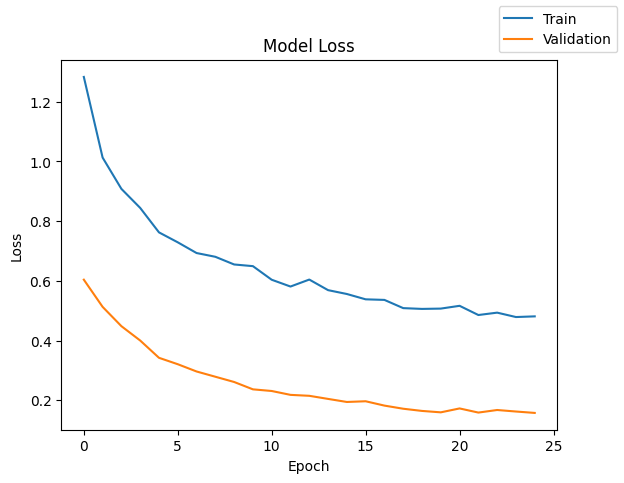

In [74]:
plot(history,'loss')

In [75]:
# Get the train and validation set recall values
model = model_6
model_6_train_perf = model_performance_classification(model, X_train, y_train)
model_6_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_6_train_perf["Recall"].values[0]
val_recall = model_6_val_perf["Recall"].values[0]

# and other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [[128, 64, 64]] #[str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [['relu', 'relu', 'relu']] #[model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = ['GlorotUniform', 'GlorotUniform', 'GlorotUniform'] #[model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "Dropout [0.4, 0.2, 0.2]"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [76]:
results.loc[6] = [count_of_layers,[neuron_counts], [activation_functions], epochs, batch_size, optimizer, [learning_rate, mom], w_initializers, regularization, train_loss, val_loss, train_recall, val_recall, round(end-start,2)]

In [77]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train Recall,validation Recall,time (secs)
0,1,[[128]],[[relu]],25,64,SGD,"[0.01, 0.0]",[GlorotUniform],-,0.075109,0.076990,0.720721,0.693694,21.63
1,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.01, 0.6]","[GlorotUniform, GlorotUniform]",-,0.211509,0.152331,0.958333,0.923423,30.46
2,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.001, 0.7]","[GlorotUniform, GlorotUniform]",-,0.090856,0.091982,0.629505,0.603604,28.88
3,2,"[[128, 64]]","[[relu, tanh]]",25,64,SGD,"[0.0001, 0.9]","[GlorotUniform, GlorotUniform]",-,0.138041,0.142223,0.262387,0.243243,30.92
4,3,"[[128, 64, 64]]","[[relu, relu, relu]]",25,64,adam,"[0.001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]",-,0.018554,0.080206,0.938063,0.914414,31.68
5,3,"[[128, 64, 64]]","[[relu, relu, relu]]",25,64,adam,"[0.0001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]",-,0.036305,0.042635,0.889640,0.900901,34.35
6,6,"[[[128, 64, 64]]]","[[[relu, relu, relu]]]",25,64,adam,"[0.0001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]","Dropout [0.4, 0.2, 0.2]",0.481016,0.157515,0.902027,0.914414,34.11


- *This model has increased the loss function.*
- *The validation recall score has improved a small bit from the previous model.*
- *This model has also taken the most time to run - 45 seconds.*
- *We will try one more experiment with changing the weight initializers to check if we can get more improvements.*

## Model 7

In [78]:
# Clearing session
tf.keras.backend.clear_session()

In [79]:
# Defining model 7 with same values as model 6 but
# we will use the He-normal weight initializer for all the layers

model_7 = Sequential()
model_7.add(Dense(128 ,activation="relu",kernel_initializer="he_normal",input_dim=X_train.shape[1]))
model_7.add(Dropout(0.4))
model_7.add(Dense(64,activation="relu",kernel_initializer="he_normal"))
model_7.add(Dropout(0.2))
model_7.add(Dense(64,activation="relu",kernel_initializer="he_normal"))
model_7.add(Dropout(0.2))
model_7.add(Dense(1,activation="sigmoid",kernel_initializer="he_normal"))
model_7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# Using Adam as the optimizer with learning rate of .0001 as we did in model 6
# Since Adam does not have a momentum parameter, leaving it as -
mom = "-"
learning_rate = 0.0001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_7.compile(loss='binary_crossentropy', optimizer=optimizer)

In [81]:
# Fit the model
# with all the defined values

start = time.time()
history = model_7.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4531 - val_loss: 0.2143
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2492 - val_loss: 0.1757
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2146 - val_loss: 0.1551
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1833 - val_loss: 0.1407
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1693 - val_loss: 0.1301
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1610 - val_loss: 0.1210
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1537 - val_loss: 0.1138
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1497 - val_loss: 0.1072
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1403 - val_loss: 0.1015
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1307 - val_loss: 0.0968
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1287 - val_loss: 0.0915
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

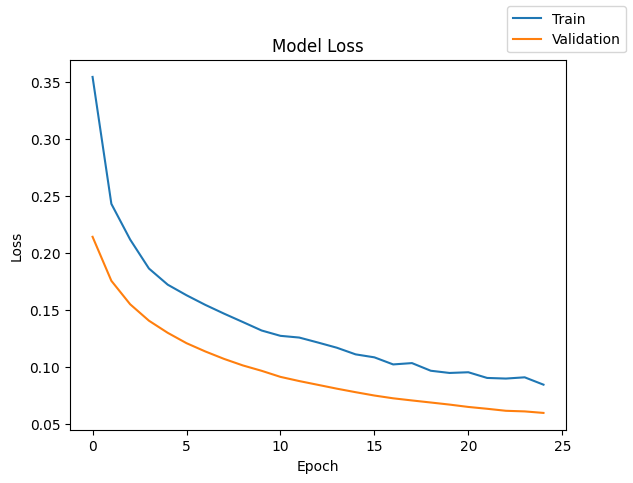

In [82]:
plot(history,'loss')

In [83]:
# Get the train and validation set recall values
model = model_7
model_7_train_perf = model_performance_classification(model, X_train, y_train)
model_7_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_7_train_perf["Recall"].values[0]
val_recall = model_7_val_perf["Recall"].values[0]

# and other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [[128, 64, 64]] #[str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [['relu', 'relu', 'relu']] #[model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = ['He_normal', 'He_normal', 'He_normal'] #[model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "Dropout [0.4, 0.2, 0.2]"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [84]:
results.loc[7] = [count_of_layers,[neuron_counts], [activation_functions], epochs, batch_size, optimizer, [learning_rate, mom], w_initializers,regularization, train_loss, val_loss, train_recall, val_recall, round(end-start,2)]

In [85]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train Recall,validation Recall,time (secs)
0,1,[[128]],[[relu]],25,64,SGD,"[0.01, 0.0]",[GlorotUniform],-,0.075109,0.076990,0.720721,0.693694,21.63
1,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.01, 0.6]","[GlorotUniform, GlorotUniform]",-,0.211509,0.152331,0.958333,0.923423,30.46
2,2,"[[128, 64]]","[[relu, relu]]",25,64,SGD,"[0.001, 0.7]","[GlorotUniform, GlorotUniform]",-,0.090856,0.091982,0.629505,0.603604,28.88
3,2,"[[128, 64]]","[[relu, tanh]]",25,64,SGD,"[0.0001, 0.9]","[GlorotUniform, GlorotUniform]",-,0.138041,0.142223,0.262387,0.243243,30.92
4,3,"[[128, 64, 64]]","[[relu, relu, relu]]",25,64,adam,"[0.001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]",-,0.018554,0.080206,0.938063,0.914414,31.68
5,3,"[[128, 64, 64]]","[[relu, relu, relu]]",25,64,adam,"[0.0001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]",-,0.036305,0.042635,0.889640,0.900901,34.35
6,6,"[[[128, 64, 64]]]","[[[relu, relu, relu]]]",25,64,adam,"[0.0001, -]","[GlorotUniform, GlorotUniform, GlorotUniform]","Dropout [0.4, 0.2, 0.2]",0.481016,0.157515,0.902027,0.914414,34.11
7,6,"[[[128, 64, 64]]]","[[[relu, relu, relu]]]",25,64,adam,"[0.0001, -]","[He_normal, He_normal, He_normal]","Dropout [0.4, 0.2, 0.2]",0.084620,0.059835,0.788288,0.774775,33.60


- *This model has not improved any of our scores.*
- *We have increased the loss for both train and validation which is not good.*
- *We have also gotten reduced train and validation recall scores compared to the previous model.*
- *Next we will choose our best model.*

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T,
        model_7_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Neural Network (SGD, 1 layer, learn rate .01)",
    "Neural Network (SGD with Momentum 0.6, 2 layers, learn rate .01)",
    "Neural Network (SGD with Momentum 0.7, 2 layers, learn rate .001)",
    "Neural Network (SGD with Momentum 0.9, 2 layers, learn rate .0001)",
    "Neural Network (Adam, 3 layers, , learn rate .001)",
    "Neural Network (Adam, 3 layers, learn rate .0001)",
    "Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2])",
    "Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2] ,He initialization)"
]

In [ ]:
models_train_comp_df

,"Neural Network (SGD, 1 layer, learn rate .01)","Neural Network (SGD with Momentum 0.6, 2 layers, learn rate .01)","Neural Network (SGD with Momentum 0.7, 2 layers, learn rate .001)","Neural Network (SGD with Momentum 0.9, 2 layers, learn rate .0001)","Neural Network (Adam, 3 layers, , learn rate .001)","Neural Network (Adam, 3 layers, learn rate .0001)","Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2])","Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2] ,He initialization)"
Accuracy,0.984250,0.946187,0.967625,0.931750,0.972562,0.977187,0.971812,0.961313
Recall,0.984250,0.946187,0.967625,0.931750,0.972562,0.977187,0.971812,0.961313
Precision,0.984214,0.970323,0.975570,0.963188,0.981339,0.981047,0.977120,0.971972
F1 Score,0.983149,0.953743,0.970193,0.942281,0.975025,0.978431,0.973584,0.964836


In [ ]:
#Validation performance comparison

models_val_comp_df = pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T,
        model_7_val_perf.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Neural Network (SGD, 1 layer, learn rate .01)",
    "Neural Network (SGD with Momentum 0.6, 2 layers, learn rate .01)",
    "Neural Network (SGD with Momentum 0.7, 2 layers, learn rate .001)",
    "Neural Network (SGD with Momentum 0.9, 2 layers, learn rate .0001)",
    "Neural Network (Adam, 3 layers, learn rate .001)",
    "Neural Network (Adam, 3 layers, learn rate .0001)",
    "Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2])",
    "Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2] ,He initialization)"
]

In [ ]:
models_val_comp_df

,"Neural Network (SGD, 1 layer, learn rate .01)","Neural Network (SGD with Momentum 0.6, 2 layers, learn rate .01)","Neural Network (SGD with Momentum 0.7, 2 layers, learn rate .001)","Neural Network (SGD with Momentum 0.9, 2 layers, learn rate .0001)","Neural Network (Adam, 3 layers, learn rate .001)","Neural Network (Adam, 3 layers, learn rate .0001)","Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2])","Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2] ,He initialization)"
Accuracy,0.984750,0.937500,0.970000,0.938750,0.961000,0.977500,0.978750,0.965250
Recall,0.984750,0.937500,0.970000,0.938750,0.961000,0.977500,0.978750,0.965250
Precision,0.984890,0.965698,0.976705,0.966006,0.972734,0.980956,0.981573,0.974500
F1 Score,0.983641,0.946753,0.972174,0.947681,0.964785,0.978639,0.979701,0.968235


In [ ]:
# Getting the difference between validation and train recall scores from the models
models_train_comp_df.loc["Recall"] - models_val_comp_df.loc["Recall"]

,Recall
"Neural Network (Adam, 3 layers, , learn rate .001)",NaN
"Neural Network (Adam, 3 layers, learn rate .0001)",-0.000313
"Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2] ,He initialization)",-0.003938
"Neural Network (Adam, 3 layers, learn rate .0001, dropout [0.4,0.2,0.2])",-0.006938
"Neural Network (Adam, 3 layers, learn rate .001)",NaN
"Neural Network (SGD with Momentum 0.6, 2 layers, learn rate .01)",0.008687
"Neural Network (SGD with Momentum 0.7, 2 layers, learn rate .001)",-0.002375
"Neural Network (SGD with Momentum 0.9, 2 layers, learn rate .0001)",-0.007000
"Neural Network (SGD, 1 layer, learn rate .01)",-0.000500


- Final Model: **Neural Network (SGD, 1 layer, learn rate .01)**
- Reasoning:
  - It has the best recall scores on both the validation and train set without any overfitting.
  - It also has the best F1 scores among all the other models, showing that it is overall more accurate than the others.
  - When considering validation scores only, Model 0 outperforms others, even though it was the first model we had and it does not have much parameter tuning.

Now, let's check the performance of the final model on the test set.

In [ ]:
final_model = model_0
model_0_test_perf = model_performance_classification(final_model, X_test, y_test)
model_0_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9814,0.9814,0.981287,0.979876


- *We observe that this initial model has given us very good recall scores on the test data also which is consistent with the train and validation data scores.*
- *Even though we didnt do any tuning on this model, it has given us the best results.*

# **Actionable Insights and Recommendations**

- *Renewind should deploy the final selected model from this exercise to identify if a turbine will fail and take action based on the model prediction.*
- *Since the model we selected has 99 percent of recall score on the test set, Renewind can be confident of relying on its prediction for failure of models.*
- *Renewind could further enhance this model so that it predicts a probability of failure, and depending on a threshold that it sets - for example probability greater than 60 percent, inspect those turbines, which might lead to more better outcomes.*
- *Further refineement for the high class imbalance could be done by using ensemble methods like SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance, as this could lead to more accurate forecasts and avoid biased predictions.*

In [ ]:
# Clearing session
tf.keras.backend.clear_session()

In [ ]:
# Defining model 1 with one more hidden layer of 64 neurons with relu activation function
# Adding class weights and momentum also
model_8 = Sequential()
model_8.add(Dense(128 ,activation="relu",input_dim=X_train.shape[1]))
model_8.add(Dense(64,activation="relu"))
model_8.add(Dense(1,activation="sigmoid"))
model_8.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Using SGD as the optimizer with momentum of 0.6
mom = 0.6
optimizer = tf.keras.optimizers.SGD(momentum=mom)
model_8.compile(loss='binary_crossentropy', optimizer=optimizer)

In [ ]:
# Fit the model with all the values defined above
# Using start and end variables to capture the time it took to run
# Also setting the class weights defined earlier
start = time.time()
history = model_8.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2739 - val_loss: 0.1374
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1230 - val_loss: 0.1052
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0988 - val_loss: 0.0893
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0858 - val_loss: 0.0795
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0773 - val_loss: 0.0729
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0713 - val_loss: 0.0682
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0669 - val_loss: 0.0648
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0635 - val_loss: 0.0623
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0609 - val_loss: 0.0603
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0587 - val_loss: 0.0588
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0569 - val_loss: 0.0576
Epoch 12/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

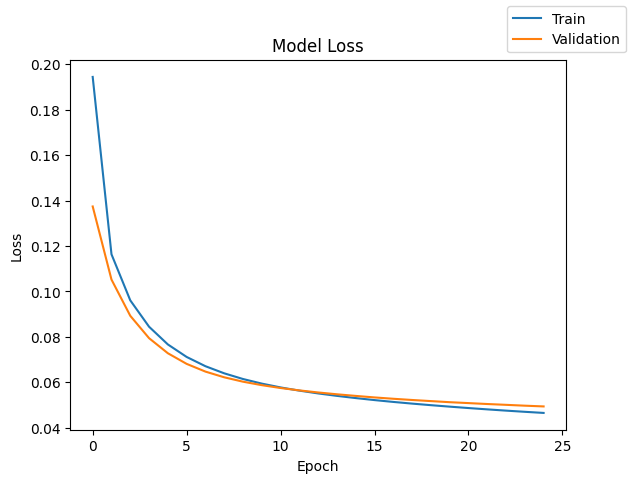

In [ ]:
plot(history,'loss')

In [ ]:
# Get the train and validation set recall values
model = model_8
model_8_train_perf = model_performance_classification(model, X_train, y_train)
model_8_val_perf = model_performance_classification(model, X_val, y_val)
train_recall = model_8_train_perf["Recall"].values[0]
val_recall = model_8_val_perf["Recall"].values[0]

# and other values for the results dataframe
count_of_layers = len(model.layers) -1
neuron_counts = [str(model.layers[i].units) for i in range(count_of_layers)]
activation_functions = [model.layers[i].get_config()["activation"]  for i in range(count_of_layers)]
w_initializers = [model.layers[i].get_config()["kernel_initializer"]['class_name'] for i in range(count_of_layers)]
optimizer = model.optimizer.get_config()["name"]
regularization = "-"
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
model_8_val_perf

,Accuracy,Recall,Precision,F1 Score
0,0.9915,0.9915,0.991376,0.991291
